# OPPORTUNITY Activity Recognition Dataset - IoT-Enhanced Process Mining Pipeline

This notebook demonstrates the complete pipeline for analyzing human activity recognition data from the OPPORTUNITY dataset. The pipeline includes:

1. **Data Loading & Exploration**: Load multimodal sensor data from wearable, object, and ambient sensors
2. **Event Abstraction**: Transform sensor readings and labels into discrete process events (gestures/activities)
3. **Data Quality Detection**: Identify missing data (NaN), sensor dropout, and annotation quality issues
4. **Process Mining**: Discover activity patterns, analyze gesture sequences, compare ADL vs. Drill runs
5. **Conformance Checking**: Validate activity execution against expected patterns
6. **Explainability**: Generate insights about sensor importance and activity recognition quality

**Dataset Context**:
- **Source**: OPPORTUNITY Project (ETH Zurich, EPFL, et al.)
- **Domain**: Human Activity Recognition / Ambient Assisted Living
- **Subjects**: 4 users
- **Recordings**: 24 runs (20 ADL + 4 Drill runs)
- **Sensors**: 250 columns (243 sensor channels + 7 label tracks)
  - Body-worn: 7 IMUs, 12 accelerometers, 4 localization tags
  - Objects: 12 instrumented items (cups, knives, etc.)
  - Ambient: 13 reed switches, 8 furniture accelerometers
- **Sampling Rate**: 30 Hz
- **Activities**: Multi-level annotations (locomotion, gestures, high-level activities)

## 1. Setup and Configuration

In [214]:
import sys
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime, timedelta
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

# Add project root to path
project_root = os.path.abspath('../..')
if project_root not in sys.path:
    sys.path.insert(0, project_root)

# Import PM4Py
import pm4py
from pm4py.objects.log.obj import EventLog, Trace, Event
from pm4py.objects.conversion.log import converter as log_converter
from pm4py.algo.discovery.inductive import algorithm as inductive_miner
from pm4py.algo.conformance.tokenreplay import algorithm as token_replay
from pm4py.visualization.petri_net import visualizer as pn_visualizer
from pm4py.visualization.dfg import visualizer as dfg_visualizer
from pm4py.algo.discovery.dfg import algorithm as dfg_discovery

# Import framework components
from src.data_quality.detectors import QualityIssueDetector
from src.explainability.insights import InsightGenerator

# Set display options
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 1000)
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (15, 6)

print(" Libraries and framework components imported successfully")
print(f" Project root: {project_root}")

 Libraries and framework components imported successfully
 Project root: /Users/christianimenkamp/Documents/Git-Repositorys/Data Quality Issues


## 2. Data Loading and Initial Exploration

The OPPORTUNITY dataset contains multi-modal sensor data from:
- **Body-worn sensors**: IMUs (BACK, arms, legs), accelerometers, localization tags
- **Object sensors**: Instrumented everyday items (cup, knife, milk, etc.)
- **Ambient sensors**: Reed switches on furniture, accelerometers on doors/drawers

Each recording captures either:
- **ADL (Activity of Daily Living) runs**: Natural, free-form execution of morning routine scenarios
- **Drill runs**: Scripted, repetitive sequences with 20 repetitions for generating labeled instances

In [215]:
# Define data paths
data_dir = '../../data/OPPORTUNITY/dataset'
label_legend_path = os.path.join(data_dir, 'label_legend.txt')
column_names_path = os.path.join(data_dir, 'column_names.txt')

print(" OPPORTUNITY Dataset Structure")
print("=" * 80)

# List available data files
data_files = [f for f in os.listdir(data_dir) if f.endswith('.dat')]
data_files_sorted = sorted(data_files)

print(f"\n Available recordings: {len(data_files_sorted)} files")
print("\nSubject-Run breakdown:")
for subject in ['S1', 'S2', 'S3', 'S4']:
    subject_files = [f for f in data_files_sorted if f.startswith(subject)]
    adl_files = [f for f in subject_files if 'ADL' in f]
    drill_files = [f for f in subject_files if 'Drill' in f]
    print(f"  {subject}: {len(adl_files)} ADL runs + {len(drill_files)} Drill run = {len(subject_files)} total")

print("\nFirst 10 files:")
for f in data_files_sorted[:10]:
    print(f"  - {f}")

 OPPORTUNITY Dataset Structure

 Available recordings: 24 files

Subject-Run breakdown:
  S1: 5 ADL runs + 1 Drill run = 6 total
  S2: 5 ADL runs + 1 Drill run = 6 total
  S3: 5 ADL runs + 1 Drill run = 6 total
  S4: 5 ADL runs + 1 Drill run = 6 total

First 10 files:
  - S1-ADL1.dat
  - S1-ADL2.dat
  - S1-ADL3.dat
  - S1-ADL4.dat
  - S1-ADL5.dat
  - S1-Drill.dat
  - S2-ADL1.dat
  - S2-ADL2.dat
  - S2-ADL3.dat
  - S2-ADL4.dat


In [216]:
# Load label legend to understand activity labels
print("\n Loading label legend...")

# Parse label legend
label_legend = {}
with open(label_legend_path, 'r') as f:
    lines = f.readlines()
    for line in lines[1:]:  # Skip header
        if line.strip() and '-' in line:
            parts = line.strip().split('-')
            if len(parts) >= 3:
                label_id = parts[0].strip()
                track = parts[1].strip()
                name = parts[2].strip()
                try:
                    label_legend[int(label_id)] = {'track': track, 'name': name}
                except ValueError:
                    continue

print(f" Loaded {len(label_legend)} activity labels")

# Display key gesture labels (mid-level)
print("\n Mid-Level Gesture Labels (ML_Both_Arms - Column 250):")
ml_gestures = {k: v for k, v in label_legend.items() if v['track'] == 'ML_Both_Arms'}
for label_id, info in sorted(ml_gestures.items()):
    print(f"  {label_id:6d} - {info['name']}")


 Loading label legend...
 Loaded 98 activity labels

 Mid-Level Gesture Labels (ML_Both_Arms - Column 250):
  404505 - Close Dishwasher
  404508 - Close Drawer 3
  404511 - Close Drawer 2
  404516 - Close Door 1
  404517 - Close Door 2
  404519 - Close Drawer 1
  404520 - Close Fridge
  405506 - Toggle Switch
  406505 - Open Dishwasher
  406508 - Open Drawer 3
  406511 - Open Drawer 2
  406516 - Open Door 1
  406517 - Open Door 2
  406519 - Open Drawer 1
  406520 - Open Fridge
  407521 - Drink from Cup
  408512 - Clean Table


In [217]:
# Load locomotion labels
print("\n Locomotion Labels (Column 244):")
locomotion = {k: v for k, v in label_legend.items() if v['track'] == 'Locomotion'}
for label_id, info in sorted(locomotion.items()):
    print(f"  {label_id:6d} - {info['name']}")

# Load high-level activity labels
print("\n High-Level Activity Labels (Column 245):")
hl_activities = {k: v for k, v in label_legend.items() if v['track'] == 'HL_Activity'}
for label_id, info in sorted(hl_activities.items()):
    print(f"  {label_id:6d} - {info['name']}")


 Locomotion Labels (Column 244):
       1 - Stand
       2 - Walk
       4 - Sit
       5 - Lie

 High-Level Activity Labels (Column 245):
     101 - Relaxing
     102 - Coffee time
     103 - Early morning
     104 - Cleanup
     105 - Sandwich time


### Load All Recordings

Load all 24 recordings from the OPPORTUNITY dataset (4 subjects × 6 runs each: 5 ADL runs + 1 Drill run per subject).

In [218]:
def load_opportunity_file(filepath):
    """
    Load OPPORTUNITY .dat file with 250 columns.
    
    Returns:
        DataFrame with columns: timestamp, sensors (242 channels), labels (7 tracks)
    """
    print(f"  Loading {os.path.basename(filepath)}...")
    
    # Read space-delimited file
    df = pd.read_csv(filepath, sep=' ', header=None, na_values='NaN')
    
    # Column names
    col_names = ['timestamp'] + [f'sensor_{i}' for i in range(2, 244)] + \
                ['locomotion', 'hl_activity', 'll_left_arm', 'll_left_arm_obj', 
                 'll_right_arm', 'll_right_arm_obj', 'ml_both_arms']
    
    df.columns = col_names
    
    # Convert timestamp to datetime (milliseconds since epoch)
    df['timestamp'] = pd.to_datetime(df['timestamp'], unit='ms')
    
    return df

# Load all 24 recordings
print("\n Loading all OPPORTUNITY recordings...")
print("=" * 80)

all_dataframes = {}
subjects = ['S1', 'S2', 'S3', 'S4']

for subject in subjects:
    print(f"\n Loading {subject}...")
    
    # Load ADL runs (ADL1-ADL5)
    for adl_num in range(1, 6):
        filename = f"{subject}-ADL{adl_num}.dat"
        filepath = os.path.join(data_dir, filename)
        
        if os.path.exists(filepath):
            df = load_opportunity_file(filepath)
            run_id = f"{subject}_ADL{adl_num}"
            all_dataframes[run_id] = df
            print(f"    {filename}: {df.shape[0]:,} samples, {(df['timestamp'].max() - df['timestamp'].min()).total_seconds():.1f}s")
        else:
            print(f"     {filename} not found")
    
    # Load Drill run
    filename = f"{subject}-Drill.dat"
    filepath = os.path.join(data_dir, filename)
    
    if os.path.exists(filepath):
        df = load_opportunity_file(filepath)
        run_id = f"{subject}_Drill"
        all_dataframes[run_id] = df
        print(f"    {filename}: {df.shape[0]:,} samples, {(df['timestamp'].max() - df['timestamp'].min()).total_seconds():.1f}s")
    else:
        print(f"     {filename} not found")

print(f"\n Loaded {len(all_dataframes)} recordings successfully")
print(f"   Total samples: {sum(len(df) for df in all_dataframes.values()):,}")
print(f"   Total duration: {sum((df['timestamp'].max() - df['timestamp'].min()).total_seconds() for df in all_dataframes.values()):.1f} seconds")


 Loading all OPPORTUNITY recordings...

 Loading S1...
  Loading S1-ADL1.dat...
    S1-ADL1.dat: 51,116 samples, 1703.8s
  Loading S1-ADL2.dat...
    S1-ADL2.dat: 32,224 samples, 1074.1s
  Loading S1-ADL3.dat...
    S1-ADL3.dat: 33,273 samples, 1109.1s
  Loading S1-ADL4.dat...
    S1-ADL4.dat: 32,955 samples, 1098.5s
  Loading S1-ADL5.dat...
    S1-ADL5.dat: 30,127 samples, 1004.2s
  Loading S1-Drill.dat...
    S1-Drill.dat: 54,966 samples, 1832.1s

 Loading S2...
  Loading S2-ADL1.dat...
    S2-ADL1.dat: 42,797 samples, 1426.5s
  Loading S2-ADL2.dat...
    S2-ADL2.dat: 30,182 samples, 1006.0s
  Loading S2-ADL3.dat...
    S2-ADL3.dat: 34,232 samples, 1141.0s
  Loading S2-ADL4.dat...
    S2-ADL4.dat: 32,748 samples, 1091.6s
  Loading S2-ADL5.dat...
    S2-ADL5.dat: 31,826 samples, 1060.8s
  Loading S2-Drill.dat...
    S2-Drill.dat: 53,398 samples, 1779.9s

 Loading S3...
  Loading S3-ADL1.dat...
    S3-ADL1.dat: 37,223 samples, 1240.7s
  Loading S3-ADL2.dat...
    S3-ADL2.dat: 27,825 s

In [219]:
# Display summary statistics by subject
print("\n Summary by Subject:")
print("=" * 80)

for subject in subjects:
    subject_runs = [k for k in all_dataframes.keys() if k.startswith(subject)]
    adl_runs = [k for k in subject_runs if 'ADL' in k]
    drill_runs = [k for k in subject_runs if 'Drill' in k]
    
    total_samples = sum(len(all_dataframes[run]) for run in subject_runs)
    total_duration = sum((all_dataframes[run]['timestamp'].max() - all_dataframes[run]['timestamp'].min()).total_seconds() 
                        for run in subject_runs)
    
    print(f"\n{subject}:")
    print(f"   Runs: {len(adl_runs)} ADL + {len(drill_runs)} Drill = {len(subject_runs)} total")
    print(f"   Samples: {total_samples:,}")
    print(f"   Duration: {total_duration:.1f}s ({total_duration/60:.1f} min)")


 Summary by Subject:

S1:
   Runs: 5 ADL + 1 Drill = 6 total
   Samples: 234,661
   Duration: 7821.8s (130.4 min)

S2:
   Runs: 5 ADL + 1 Drill = 6 total
   Samples: 225,183
   Duration: 7505.8s (125.1 min)

S3:
   Runs: 5 ADL + 1 Drill = 6 total
   Samples: 216,869
   Duration: 7228.7s (120.5 min)

S4:
   Runs: 5 ADL + 1 Drill = 6 total
   Samples: 192,674
   Duration: 6422.2s (107.0 min)


In [220]:
# Display sample data from first recording
first_run = list(all_dataframes.keys())[0]
sample_df = all_dataframes[first_run]

print(f"\n Sample data structure ({first_run}, first 5 rows):")
print(sample_df.head())

print(f"\n Data summary:")
print(f"  Total columns: {len(sample_df.columns)}")
print(f"  Sensor columns: {len([c for c in sample_df.columns if c.startswith('sensor_')])}")
print(f"  Label columns: {len([c for c in sample_df.columns if c in ['locomotion', 'hl_activity', 'll_left_arm', 'll_left_arm_obj', 'll_right_arm', 'll_right_arm_obj', 'ml_both_arms']])}")


 Sample data structure (S1_ADL1, first 5 rows):
                timestamp  sensor_2  sensor_3  sensor_4  sensor_5  sensor_6  sensor_7  sensor_8  sensor_9  sensor_10  sensor_11  sensor_12  sensor_13  sensor_14  sensor_15  sensor_16  sensor_17  sensor_18  sensor_19  sensor_20  sensor_21  sensor_22  sensor_23  sensor_24  sensor_25  sensor_26  sensor_27  sensor_28  sensor_29  sensor_30  sensor_31  sensor_32  sensor_33  sensor_34  sensor_35  sensor_36  sensor_37  sensor_38  sensor_39  sensor_40  sensor_41  sensor_42  sensor_43  sensor_44  sensor_45  sensor_46  sensor_47  sensor_48  sensor_49  sensor_50  sensor_51  sensor_52  sensor_53  sensor_54  sensor_55  sensor_56  sensor_57  sensor_58  sensor_59  sensor_60  sensor_61  sensor_62  sensor_63  sensor_64  sensor_65  sensor_66  sensor_67  sensor_68  sensor_69  sensor_70  sensor_71  sensor_72  sensor_73  sensor_74  sensor_75  sensor_76  sensor_77  sensor_78  sensor_79  sensor_80  sensor_81  sensor_82  sensor_83  sensor_84  sensor_85  sensor_8

## 3. Data Quality Analysis

Analyze the dataset for quality issues including:
- **Missing data (NaN)**: Expected in wireless sensors (objects, body-worn accelerometers)
- **Sensor completeness**: Track which sensors have data
- **Label coverage**: Check annotation completeness

In [221]:
# Analyze missing data across all recordings
print(" Data Quality Analysis - Missing Data (NaN)")
print("=" * 80)

sensor_cols = [c for c in sample_df.columns if c.startswith('sensor_')]

# Aggregate NaN statistics across all recordings
all_nan_stats = {}

for run_id, df in all_dataframes.items():
    for col in sensor_cols:
        if col not in all_nan_stats:
            all_nan_stats[col] = {'total_samples': 0, 'nan_count': 0, 'recordings_affected': []}
        
        nan_count = df[col].isna().sum()
        all_nan_stats[col]['total_samples'] += len(df)
        all_nan_stats[col]['nan_count'] += nan_count
        
        if nan_count > 0:
            all_nan_stats[col]['recordings_affected'].append(run_id)

# Calculate overall NaN percentages
for col in all_nan_stats:
    stats = all_nan_stats[col]
    stats['nan_pct'] = (stats['nan_count'] / stats['total_samples'] * 100) if stats['total_samples'] > 0 else 0

print(f"\n Overall NaN Statistics (All {len(all_dataframes)} recordings):")
sensors_with_nan = sum(1 for stats in all_nan_stats.values() if stats['nan_pct'] > 0)
print(f"   Sensors with NaN: {sensors_with_nan} / {len(sensor_cols)}")
print(f"   Clean sensors: {len(sensor_cols) - sensors_with_nan}")

# Show top 10 sensors with most NaN
sorted_nan = sorted(all_nan_stats.items(), key=lambda x: x[1]['nan_pct'], reverse=True)
print(f"\n   Top 10 sensors with most missing data (across all recordings):")
for col, stats in sorted_nan[:10]:
    print(f"     {col}: {stats['nan_pct']:.2f}% missing ({stats['nan_count']:,} / {stats['total_samples']:,} samples)")
    print(f"          Affected {len(stats['recordings_affected'])} / {len(all_dataframes)} recordings")

 Data Quality Analysis - Missing Data (NaN)

 Overall NaN Statistics (All 24 recordings):
   Sensors with NaN: 242 / 242
   Clean sensors: 0

   Top 10 sensors with most missing data (across all recordings):
     sensor_35: 46.42% missing (403,589 / 869,387 samples)
          Affected 24 / 24 recordings
     sensor_36: 46.42% missing (403,589 / 869,387 samples)
          Affected 24 / 24 recordings
     sensor_37: 46.42% missing (403,589 / 869,387 samples)
          Affected 24 / 24 recordings
     sensor_14: 16.62% missing (144,469 / 869,387 samples)
          Affected 24 / 24 recordings
     sensor_15: 16.62% missing (144,469 / 869,387 samples)
          Affected 24 / 24 recordings
     sensor_16: 16.62% missing (144,469 / 869,387 samples)
          Affected 24 / 24 recordings
     sensor_23: 9.86% missing (85,754 / 869,387 samples)
          Affected 24 / 24 recordings
     sensor_24: 9.86% missing (85,754 / 869,387 samples)
          Affected 24 / 24 recordings
     sensor_25: 9.86

In [222]:
# Analyze NaN by recording type (ADL vs Drill)
print(f"\n NaN Analysis by Recording Type:")

adl_recordings = {k: v for k, v in all_dataframes.items() if 'ADL' in k}
drill_recordings = {k: v for k, v in all_dataframes.items() if 'Drill' in k}

# ADL statistics
adl_total_samples = sum(len(df) for df in adl_recordings.values()) * len(sensor_cols)
adl_total_nan = sum(df[sensor_cols].isna().sum().sum() for df in adl_recordings.values())
adl_nan_pct = (adl_total_nan / adl_total_samples * 100) if adl_total_samples > 0 else 0

print(f"\n   ADL Recordings ({len(adl_recordings)} total):")
print(f"     Average NaN: {adl_nan_pct:.2f}%")
print(f"     Total NaN values: {adl_total_nan:,} / {adl_total_samples:,}")

# Drill statistics
drill_total_samples = sum(len(df) for df in drill_recordings.values()) * len(sensor_cols)
drill_total_nan = sum(df[sensor_cols].isna().sum().sum() for df in drill_recordings.values())
drill_nan_pct = (drill_total_nan / drill_total_samples * 100) if drill_total_samples > 0 else 0

print(f"\n   Drill Recordings ({len(drill_recordings)} total):")
print(f"     Average NaN: {drill_nan_pct:.2f}%")
print(f"     Total NaN values: {drill_total_nan:,} / {drill_total_samples:,}")


 NaN Analysis by Recording Type:

   ADL Recordings (20 total):
     Average NaN: 4.05%
     Total NaN values: 6,323,812 / 156,001,670

   Drill Recordings (4 total):
     Average NaN: 3.78%
     Total NaN values: 2,056,538 / 54,389,984


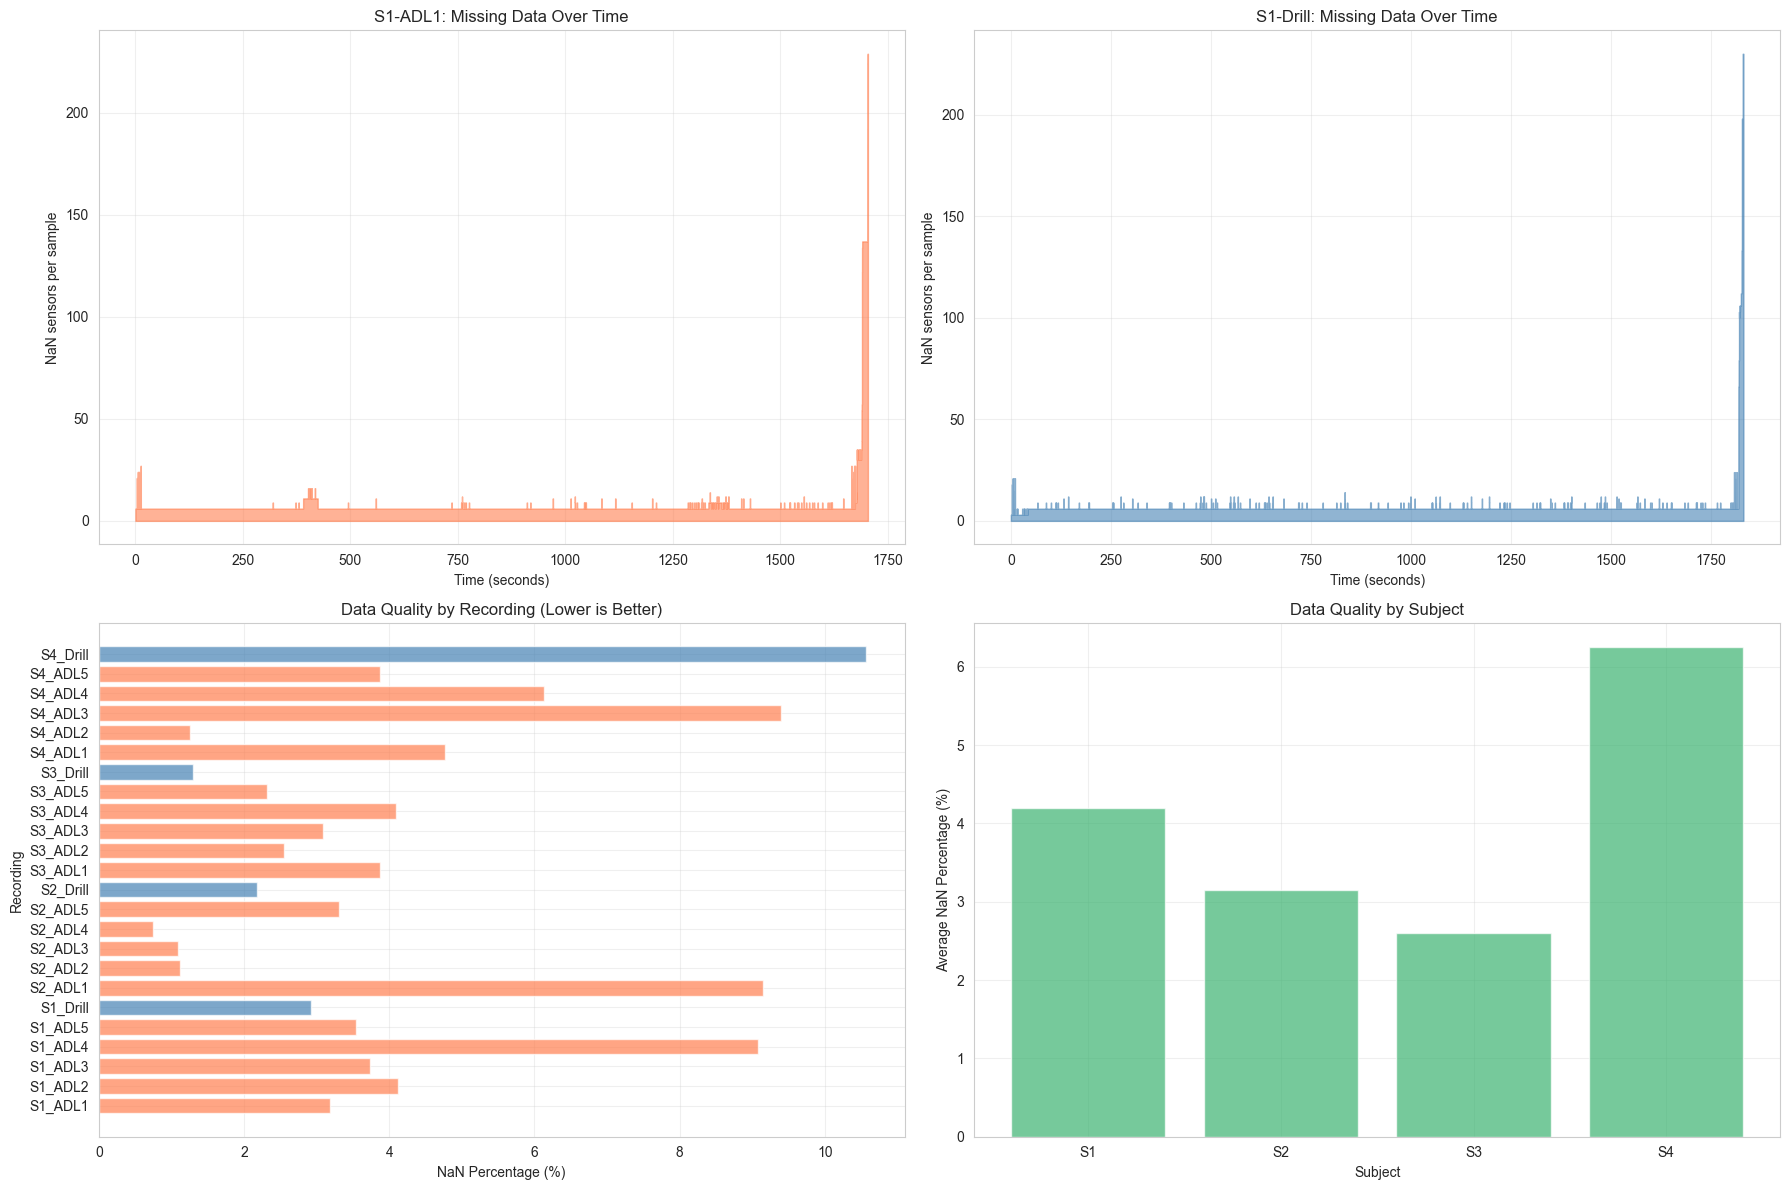


 Missing data visualization complete


In [223]:
# Visualize NaN patterns over time for sample recordings (S1-ADL1 and S1-Drill)
fig, axes = plt.subplots(2, 2, figsize=(18, 12))

# Get sample recordings for visualization
sample_adl = all_dataframes.get('S1_ADL1')
sample_drill = all_dataframes.get('S1_Drill')

if sample_adl is not None:
    # S1-ADL1 NaN over time
    nan_per_sample = sample_adl[sensor_cols].isna().sum(axis=1)
    time_seconds = (sample_adl['timestamp'] - sample_adl['timestamp'].min()).dt.total_seconds()
    
    ax1 = axes[0, 0]
    ax1.fill_between(time_seconds, nan_per_sample, alpha=0.6, color='coral')
    ax1.set_xlabel('Time (seconds)')
    ax1.set_ylabel('NaN sensors per sample')
    ax1.set_title('S1-ADL1: Missing Data Over Time')
    ax1.grid(True, alpha=0.3)

if sample_drill is not None:
    # S1-Drill NaN over time
    nan_per_sample = sample_drill[sensor_cols].isna().sum(axis=1)
    time_seconds = (sample_drill['timestamp'] - sample_drill['timestamp'].min()).dt.total_seconds()
    
    ax2 = axes[0, 1]
    ax2.fill_between(time_seconds, nan_per_sample, alpha=0.6, color='steelblue')
    ax2.set_xlabel('Time (seconds)')
    ax2.set_ylabel('NaN sensors per sample')
    ax2.set_title('S1-Drill: Missing Data Over Time')
    ax2.grid(True, alpha=0.3)

# NaN percentage by recording
ax3 = axes[1, 0]
recording_names = []
recording_nan_pcts = []

for run_id, df in all_dataframes.items():
    total_values = len(df) * len(sensor_cols)
    nan_count = df[sensor_cols].isna().sum().sum()
    nan_pct = (nan_count / total_values * 100) if total_values > 0 else 0
    
    recording_names.append(run_id)
    recording_nan_pcts.append(nan_pct)

colors = ['coral' if 'ADL' in name else 'steelblue' for name in recording_names]
ax3.barh(recording_names, recording_nan_pcts, color=colors, alpha=0.7)
ax3.set_xlabel('NaN Percentage (%)')
ax3.set_ylabel('Recording')
ax3.set_title('Data Quality by Recording (Lower is Better)')
ax3.grid(True, alpha=0.3)

# Average NaN by subject
ax4 = axes[1, 1]
subject_nan = {}
for subject in subjects:
    subject_recordings = {k: v for k, v in all_dataframes.items() if k.startswith(subject)}
    total_values = sum(len(df) * len(sensor_cols) for df in subject_recordings.values())
    total_nan = sum(df[sensor_cols].isna().sum().sum() for df in subject_recordings.values())
    subject_nan[subject] = (total_nan / total_values * 100) if total_values > 0 else 0

ax4.bar(subject_nan.keys(), subject_nan.values(), color='mediumseagreen', alpha=0.7)
ax4.set_xlabel('Subject')
ax4.set_ylabel('Average NaN Percentage (%)')
ax4.set_title('Data Quality by Subject')
ax4.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"\n Missing data visualization complete")

## 4. Activity Label Analysis

Analyze the multi-level activity annotations:
- **Locomotion** (Column 244): Stand, Walk, Sit, Lie
- **High-Level Activities** (Column 245): Relaxing, Coffee time, Early morning, Cleanup, Sandwich time
- **Mid-Level Gestures** (Column 250): Open/Close Door/Fridge/Drawer, Clean Table, Drink, etc.

In [224]:
# Analyze mid-level gesture labels across all recordings
print(" Mid-Level Gesture Analysis (ML_Both_Arms)")
print("=" * 80)

# Aggregate gesture statistics across all recordings
all_gesture_counts = {}
adl_gesture_counts = {}
drill_gesture_counts = {}

for run_id, df in all_dataframes.items():
    gestures = df[df['ml_both_arms'] != 0]['ml_both_arms'].value_counts()
    
    for label_id, count in gestures.items():
        label_id_int = int(label_id)
        
        # Overall counts
        all_gesture_counts[label_id_int] = all_gesture_counts.get(label_id_int, 0) + count
        
        # Separate ADL vs Drill
        if 'ADL' in run_id:
            adl_gesture_counts[label_id_int] = adl_gesture_counts.get(label_id_int, 0) + count
        else:
            drill_gesture_counts[label_id_int] = drill_gesture_counts.get(label_id_int, 0) + count

print(f"\n Overall Gesture Statistics (All recordings):")
print(f"   Unique gestures: {len(all_gesture_counts)}")
print(f"   Total gesture samples: {sum(all_gesture_counts.values()):,}")

print(f"\n   Top 10 most frequent gestures:")
sorted_gestures = sorted(all_gesture_counts.items(), key=lambda x: x[1], reverse=True)
for label_id, count in sorted_gestures[:10]:
    gesture_name = label_legend.get(label_id, {}).get('name', f'Unknown_{label_id}')
    duration_sec = count / 30  # 30 Hz sampling
    print(f"     {label_id:6d} - {gesture_name:30s}: {count:6d} samples ({duration_sec:7.1f}s)")

 Mid-Level Gesture Analysis (ML_Both_Arms)

 Overall Gesture Statistics (All recordings):
   Unique gestures: 17
   Total gesture samples: 241,021

   Top 10 most frequent gestures:
     407521 - Drink from Cup                :  53463 samples ( 1782.1s)
     406520 - Open Fridge                   :  17778 samples (  592.6s)
     408512 - Clean Table                   :  16233 samples (  541.1s)
     404520 - Close Fridge                  :  16120 samples (  537.3s)
     406517 - Open Door 2                   :  14675 samples (  489.2s)
     406516 - Open Door 1                   :  14248 samples (  474.9s)
     404517 - Close Door 2                  :  13878 samples (  462.6s)
     404516 - Close Door 1                  :  13383 samples (  446.1s)
     406505 - Open Dishwasher               :  11493 samples (  383.1s)
     405506 - Toggle Switch                 :  10979 samples (  366.0s)


In [225]:
# Compare ADL vs Drill gesture patterns
print(f"\n Gesture Comparison: ADL vs Drill:")

print(f"\n   ADL Recordings ({len(adl_recordings)} total):")
print(f"     Total gesture samples: {sum(adl_gesture_counts.values()):,}")
print(f"     Unique gestures: {len(adl_gesture_counts)}")
print(f"     Top 5 gestures:")
for label_id, count in sorted(adl_gesture_counts.items(), key=lambda x: x[1], reverse=True)[:5]:
    gesture_name = label_legend.get(label_id, {}).get('name', f'Unknown_{label_id}')
    print(f"       {gesture_name:30s}: {count:5d} samples")

print(f"\n   Drill Recordings ({len(drill_recordings)} total):")
print(f"     Total gesture samples: {sum(drill_gesture_counts.values()):,}")
print(f"     Unique gestures: {len(drill_gesture_counts)}")
print(f"     Top 5 gestures:")
for label_id, count in sorted(drill_gesture_counts.items(), key=lambda x: x[1], reverse=True)[:5]:
    gesture_name = label_legend.get(label_id, {}).get('name', f'Unknown_{label_id}')
    print(f"       {gesture_name:30s}: {count:5d} samples")


 Gesture Comparison: ADL vs Drill:

   ADL Recordings (20 total):
     Total gesture samples: 107,803
     Unique gestures: 17
     Top 5 gestures:
       Drink from Cup                : 24462 samples
       Open Fridge                   : 11523 samples
       Close Fridge                  : 10344 samples
       Clean Table                   :  6627 samples
       Open Door 1                   :  6356 samples

   Drill Recordings (4 total):
     Total gesture samples: 133,218
     Unique gestures: 17
     Top 5 gestures:
       Drink from Cup                : 29001 samples
       Clean Table                   :  9606 samples
       Close Door 2                  :  8643 samples
       Close Door 1                  :  8425 samples
       Open Door 2                   :  8319 samples


In [226]:
# Analyze locomotion labels across all recordings
print("\n Locomotion Analysis (All Recordings)")
print("=" * 80)

all_locomotion = {}
for run_id, df in all_dataframes.items():
    locs = df[df['locomotion'] != 0]['locomotion'].value_counts()
    for label_id, count in locs.items():
        label_id_int = int(label_id)
        all_locomotion[label_id_int] = all_locomotion.get(label_id_int, 0) + count

total_loc_samples = sum(all_locomotion.values())
print(f"\n Overall Locomotion Statistics:")
for label_id, count in sorted(all_locomotion.items()):
    loc_name = label_legend.get(label_id, {}).get('name', f'Unknown_{label_id}')
    pct = (count / total_loc_samples * 100) if total_loc_samples > 0 else 0
    duration = count / 30  # 30 Hz
    print(f"   {label_id:2d} - {loc_name:10s}: {count:8d} samples ({pct:5.1f}%, {duration:7.1f}s)")


 Locomotion Analysis (All Recordings)

 Overall Locomotion Statistics:
    1 - Stand     :   345397 samples ( 48.9%, 11513.2s)
    2 - Walk      :   199213 samples ( 28.2%,  6640.4s)
    4 - Sit       :   136852 samples ( 19.4%,  4561.7s)
    5 - Lie       :    25395 samples (  3.6%,   846.5s)


In [227]:
# Analyze high-level activities across all recordings
print("\n High-Level Activity Analysis (All Recordings)")
print("=" * 80)

all_hl_activities = {}
recordings_with_hl = []

for run_id, df in all_dataframes.items():
    hl_acts = df[df['hl_activity'] != 0]['hl_activity'].value_counts()
    if len(hl_acts) > 0:
        recordings_with_hl.append(run_id)
        for label_id, count in hl_acts.items():
            label_id_int = int(label_id)
            all_hl_activities[label_id_int] = all_hl_activities.get(label_id_int, 0) + count

if len(all_hl_activities) > 0:
    total_hl_samples = sum(all_hl_activities.values())
    print(f"\n Overall High-Level Activity Statistics:")
    print(f"   Recordings with HL labels: {len(recordings_with_hl)} / {len(all_dataframes)}")
    print(f"   Total HL activity samples: {total_hl_samples:,}")
    
    print(f"\n   Activity distribution:")
    for label_id, count in sorted(all_hl_activities.items()):
        activity_name = label_legend.get(label_id, {}).get('name', f'Unknown_{label_id}')
        duration_sec = count / 30
        pct = (count / total_hl_samples * 100) if total_hl_samples > 0 else 0
        print(f"     {label_id:3d} - {activity_name:20s}: {count:7d} samples ({duration_sec:7.1f}s, {pct:5.1f}%)")
else:
    print(f"\n     No high-level activity labels found (expected for Drill runs)")


 High-Level Activity Analysis (All Recordings)

 Overall High-Level Activity Statistics:
   Recordings with HL labels: 20 / 24
   Total HL activity samples: 530,578

   Activity distribution:
     101 - Relaxing            :   43941 samples ( 1464.7s,   8.3%)
     102 - Coffee time         :   88113 samples ( 2937.1s,  16.6%)
     103 - Early morning       :  138449 samples ( 4615.0s,  26.1%)
     104 - Cleanup             :   85797 samples ( 2859.9s,  16.2%)
     105 - Sandwich time       :  174278 samples ( 5809.3s,  32.8%)


## 5. Event Extraction for Process Mining

Extract discrete events from the continuous sensor data and labels. We'll focus on **mid-level gestures** (Column 250) as the primary event type, following the dataset documentation recommendations.

**Event Extraction Strategy**:
1. Detect gesture boundaries (when `ml_both_arms` label changes)
2. Create interval events with start/end times
3. Add contextual attributes (locomotion, sensor quality, movement intensity)
4. Create process mining event log in PM4Py format

In [228]:
def extract_gesture_events(df, subject_id, run_id, label_legend):
    """
    Extract mid-level gesture events from OPPORTUNITY data.
    
    Args:
        df: DataFrame with sensor data and labels
        subject_id: Subject identifier (e.g., 'S1')
        run_id: Run identifier (e.g., 'ADL1' or 'Drill')
        label_legend: Dictionary mapping label IDs to names
        
    Returns:
        List of event dictionaries
    """
    events = []
    case_id = f"{subject_id}_{run_id}"
    
    # Track current gesture
    current_gesture_id = 0
    gesture_start_time = None
    gesture_start_idx = None
    
    for idx, row in df.iterrows():
        gesture_id = int(row['ml_both_arms']) if not pd.isna(row['ml_both_arms']) else 0
        timestamp = row['timestamp']
        
        # Gesture change detected
        if gesture_id != 0 and gesture_id != current_gesture_id:
            # Close previous gesture if exists
            if current_gesture_id != 0 and gesture_start_idx is not None:
                # Get gesture window data
                window_df = df.loc[gesture_start_idx:idx-1]
                
                # Calculate attributes
                event = create_gesture_event(
                    case_id, current_gesture_id, gesture_start_time, 
                    df.loc[idx-1, 'timestamp'], window_df, label_legend
                )
                events.append(event)
            
            # Start new gesture
            current_gesture_id = gesture_id
            gesture_start_time = timestamp
            gesture_start_idx = idx
            
        # Gesture ends (transition to no-gesture state)
        elif gesture_id == 0 and current_gesture_id != 0:
            # Close current gesture
            window_df = df.loc[gesture_start_idx:idx-1]
            
            event = create_gesture_event(
                case_id, current_gesture_id, gesture_start_time,
                timestamp, window_df, label_legend
            )
            events.append(event)
            
            # Reset state
            current_gesture_id = 0
            gesture_start_time = None
            gesture_start_idx = None
    
    # Handle case where gesture continues to end of recording
    if current_gesture_id != 0 and gesture_start_idx is not None:
        window_df = df.loc[gesture_start_idx:]
        event = create_gesture_event(
            case_id, current_gesture_id, gesture_start_time,
            df.iloc[-1]['timestamp'], window_df, label_legend
        )
        events.append(event)
    
    return events

def create_gesture_event(case_id, gesture_id, start_time, end_time, window_df, label_legend):
    """
    Create a single gesture event with attributes.
    """
    # Get gesture name
    gesture_info = label_legend.get(gesture_id, {})
    gesture_name = gesture_info.get('name', f'Gesture_{gesture_id}')
    
    # Calculate duration
    duration_ms = (end_time - start_time).total_seconds() * 1000
    
    # Get locomotion context (most common in window)
    locomotion_labels = window_df['locomotion'].dropna()
    if len(locomotion_labels) > 0:
        most_common_locomotion = int(locomotion_labels.mode().iloc[0]) if len(locomotion_labels.mode()) > 0 else 0
        locomotion_name = label_legend.get(most_common_locomotion, {}).get('name', 'Unknown')
    else:
        locomotion_name = 'Unknown'
    
    # Calculate sensor data quality
    sensor_cols = [c for c in window_df.columns if c.startswith('sensor_')]
    total_sensor_readings = len(window_df) * len(sensor_cols)
    nan_count = window_df[sensor_cols].isna().sum().sum()
    nan_percentage = (nan_count / total_sensor_readings * 100) if total_sensor_readings > 0 else 0
    
    # Movement intensity (using first available IMU sensor as proxy)
    # Column 38-40 are BACK IMU accelerations
    movement_intensity = 0
    if 'sensor_38' in window_df.columns and 'sensor_39' in window_df.columns and 'sensor_40' in window_df.columns:
        acc_data = window_df[['sensor_38', 'sensor_39', 'sensor_40']].dropna()
        if len(acc_data) > 0:
            # Calculate acceleration magnitude
            acc_magnitude = np.sqrt((acc_data ** 2).sum(axis=1))
            movement_intensity = float(acc_magnitude.mean())
    
    event = {
        'case_id': case_id,
        'activity': gesture_name,
        'start_time': start_time,
        'end_time': end_time,
        'duration_ms': duration_ms,
        'gesture_id': gesture_id,
        'posture': locomotion_name,
        'nan_percentage': nan_percentage,
        'movement_intensity': movement_intensity,
        'sample_count': len(window_df)
    }
    
    return event

# Extract events from all recordings
print(" Extracting gesture events from all recordings...")
print("=" * 80)

all_events = []

for run_id, df in all_dataframes.items():
    # Parse subject and run type from run_id (e.g., "S1_ADL1" or "S1_Drill")
    parts = run_id.split('_')
    subject_id = parts[0]
    run_type = parts[1]
    
    print(f"\n Processing {run_id}...")
    events = extract_gesture_events(df, subject_id, run_type, label_legend)
    all_events.extend(events)
    print(f"    Extracted {len(events)} events")

print(f"\n Event extraction complete!")
print(f"   Total events: {len(all_events)}")
print(f"   From {len(all_dataframes)} recordings")

 Extracting gesture events from all recordings...

 Processing S1_ADL1...
    Extracted 50 events

 Processing S1_ADL2...
    Extracted 65 events

 Processing S1_ADL3...
    Extracted 49 events

 Processing S1_ADL4...
    Extracted 69 events

 Processing S1_ADL5...
    Extracted 52 events

 Processing S1_Drill...
    Extracted 379 events

 Processing S2_ADL1...
    Extracted 61 events

 Processing S2_ADL2...
    Extracted 51 events

 Processing S2_ADL3...
    Extracted 55 events

 Processing S2_ADL4...
    Extracted 52 events

 Processing S2_ADL5...
    Extracted 47 events

 Processing S2_Drill...
    Extracted 368 events

 Processing S3_ADL1...
    Extracted 62 events

 Processing S3_ADL2...
    Extracted 44 events

 Processing S3_ADL3...
    Extracted 54 events

 Processing S3_ADL4...
    Extracted 52 events

 Processing S3_ADL5...
    Extracted 53 events

 Processing S3_Drill...
    Extracted 344 events

 Processing S4_ADL1...
    Extracted 62 events

 Processing S4_ADL2...
    Extr

In [229]:
# Display extracted events summary
print("\n Event Extraction Summary:")
all_events_df = pd.DataFrame(all_events)

# Group by case (recording)
events_by_case = all_events_df.groupby('case_id').size().sort_values(ascending=False)

print(f"\n   Events per recording:")
for case_id, count in events_by_case.items():
    print(f"     {case_id:15s}: {count:4d} events")

print(f"\n   Overall statistics:")
print(f"     Total events: {len(all_events_df)}")
print(f"     Total cases: {all_events_df['case_id'].nunique()}")
print(f"     Unique activities: {all_events_df['activity'].nunique()}")
print(f"     Average duration: {all_events_df['duration_ms'].mean():.0f} ms")
print(f"     Average NaN%: {all_events_df['nan_percentage'].mean():.2f}%")


 Event Extraction Summary:

   Events per recording:
     S4_Drill       :  394 events
     S1_Drill       :  379 events
     S2_Drill       :  368 events
     S3_Drill       :  344 events
     S4_ADL5        :   72 events
     S1_ADL4        :   69 events
     S1_ADL2        :   65 events
     S4_ADL1        :   62 events
     S3_ADL1        :   62 events
     S2_ADL1        :   61 events
     S2_ADL3        :   55 events
     S3_ADL3        :   54 events
     S3_ADL5        :   53 events
     S2_ADL4        :   52 events
     S3_ADL4        :   52 events
     S1_ADL5        :   52 events
     S2_ADL2        :   51 events
     S1_ADL1        :   50 events
     S1_ADL3        :   49 events
     S2_ADL5        :   47 events
     S3_ADL2        :   44 events
     S4_ADL2        :   42 events
     S4_ADL3        :   39 events
     S4_ADL4        :   35 events

   Overall statistics:
     Total events: 2551
     Total cases: 24
     Unique activities: 17
     Average duration: 3146 ms
   

In [230]:
# Show sample events
print("\n Sample Events (first 10):")
print(all_events_df.head(10)[['case_id', 'activity', 'duration_ms', 'posture', 'nan_percentage']])

# Separate ADL and Drill events
adl_events_df = all_events_df[all_events_df['case_id'].str.contains('ADL')]
drill_events_df = all_events_df[all_events_df['case_id'].str.contains('Drill')]

print(f"\n ADL vs Drill Comparison:")
print(f"   ADL events: {len(adl_events_df)} ({len(adl_events_df)/len(all_events_df)*100:.1f}%)")
print(f"   Drill events: {len(drill_events_df)} ({len(drill_events_df)/len(all_events_df)*100:.1f}%)")


 Sample Events (first 10):
   case_id        activity  duration_ms posture  nan_percentage
0  S1_ADL1     Open Fridge       3366.0   Stand        2.479339
1  S1_ADL1    Close Fridge       1800.0   Stand        2.479339
2  S1_ADL1     Open Door 2       3867.0   Stand        2.693075
3  S1_ADL1     Open Door 1       5767.0   Stand        4.545455
4  S1_ADL1   Open Drawer 2       2067.0   Stand        6.145028
5  S1_ADL1  Close Drawer 2       1167.0   Stand        5.844156
6  S1_ADL1   Open Drawer 1       1633.0   Stand        4.545455
7  S1_ADL1  Close Drawer 1       1066.0   Stand        4.545455
8  S1_ADL1   Open Drawer 3       1600.0   Stand        5.018939
9  S1_ADL1  Close Drawer 3       3400.0   Stand        4.484686

 ADL vs Drill Comparison:
   ADL events: 1066 (41.8%)
   Drill events: 1485 (58.2%)


In [231]:
# Activity distribution across all events
print("\n Activity Distribution (All Events):")

activity_counts = all_events_df['activity'].value_counts()
print(f"\n   Total unique activities: {len(activity_counts)}")
print(f"\n   Top 15 activities:")
for activity, count in activity_counts.head(15).items():
    adl_count = len(adl_events_df[adl_events_df['activity'] == activity])
    drill_count = len(drill_events_df[drill_events_df['activity'] == activity])
    print(f"     {activity:30s}: {count:4d} total (ADL: {adl_count:3d}, Drill: {drill_count:3d})")


 Activity Distribution (All Events):

   Total unique activities: 17

   Top 15 activities:
     Drink from Cup                :  270 total (ADL: 114, Drill: 156)
     Toggle Switch                 :  216 total (ADL:  75, Drill: 141)
     Close Fridge                  :  213 total (ADL: 133, Drill:  80)
     Open Fridge                   :  209 total (ADL: 129, Drill:  80)
     Open Dishwasher               :  136 total (ADL:  56, Drill:  80)
     Close Drawer 3                :  136 total (ADL:  57, Drill:  79)
     Open Drawer 3                 :  135 total (ADL:  56, Drill:  79)
     Close Dishwasher              :  134 total (ADL:  56, Drill:  78)
     Open Drawer 1                 :  129 total (ADL:  50, Drill:  79)
     Close Drawer 1                :  128 total (ADL:  49, Drill:  79)
     Open Door 1                   :  125 total (ADL:  46, Drill:  79)
     Open Drawer 2                 :  124 total (ADL:  45, Drill:  79)
     Close Drawer 2                :  123 total (ADL:  

## 6. Process Mining - Event Log Creation

Convert extracted events into PM4Py EventLog format for process mining analysis.

In [232]:
def create_pm4py_event_log(events_list):
    """
    Convert event list to PM4Py EventLog format.
    
    Args:
        events_list: List of event dictionaries
        
    Returns:
        PM4Py EventLog object
    """
    # Sort events by case_id and start_time
    events_sorted = sorted(events_list, key=lambda x: (x['case_id'], x['start_time']))
    
    # Create EventLog
    log = EventLog()
    
    # Group by case
    current_case_id = None
    current_trace = None
    
    for event_data in events_sorted:
        # Start new trace if case changes
        if event_data['case_id'] != current_case_id:
            if current_trace is not None:
                log.append(current_trace)
            
            current_trace = Trace()
            current_trace.attributes['concept:name'] = event_data['case_id']
            current_case_id = event_data['case_id']
        
        # Create event
        event = Event()
        event['concept:name'] = event_data['activity']
        event['time:timestamp'] = event_data['start_time']
        event['duration'] = event_data['duration_ms']
        event['posture'] = event_data.get('posture', 'Unknown')
        event['nan_percentage'] = event_data.get('nan_percentage', 0)
        event['movement_intensity'] = event_data.get('movement_intensity', 0)
        event['gesture_id'] = event_data.get('gesture_id', 0)
        
        current_trace.append(event)
    
    # Add final trace
    if current_trace is not None:
        log.append(current_trace)
    
    return log

# Create event logs
print(" Creating PM4Py event logs...")

# Create main event log from all events
event_log = create_pm4py_event_log(all_events)

print(f" Event log created successfully")
print(f"   Cases (traces): {len(event_log)}")
print(f"   Total events: {sum(len(trace) for trace in event_log)}")

# Display trace summary (first 10 and last 5 traces)
print(f"\n   First 10 traces:")
for trace in event_log[:10]:
    case_name = trace.attributes['concept:name']
    num_events = len(trace)
    activities = [event['concept:name'] for event in trace]
    print(f"     {case_name:15s}: {num_events:3d} events - {', '.join(activities[:3])}{'...' if len(activities) > 3 else ''}")

if len(event_log) > 15:
    print(f"\n   ... ({len(event_log) - 15} traces omitted) ...")
    print(f"\n   Last 5 traces:")
    for trace in event_log[-5:]:
        case_name = trace.attributes['concept:name']
        num_events = len(trace)
        activities = [event['concept:name'] for event in trace]
        print(f"     {case_name:15s}: {num_events:3d} events - {', '.join(activities[:3])}{'...' if len(activities) > 3 else ''}")

 Creating PM4Py event logs...
 Event log created successfully
   Cases (traces): 24
   Total events: 2551

   First 10 traces:
     S1_ADL1        :  50 events - Open Fridge, Close Fridge, Open Door 2...
     S1_ADL2        :  65 events - Open Door 1, Toggle Switch, Toggle Switch...
     S1_ADL3        :  49 events - Toggle Switch, Close Door 1, Open Drawer 1...
     S1_ADL4        :  69 events - Toggle Switch, Open Drawer 2, Close Drawer 2...
     S1_ADL5        :  52 events - Toggle Switch, Toggle Switch, Open Door 2...
     S1_Drill       : 379 events - Open Fridge, Close Fridge, Open Dishwasher...
     S2_ADL1        :  61 events - Toggle Switch, Open Drawer 1, Close Drawer 1...
     S2_ADL2        :  51 events - Toggle Switch, Open Door 2, Open Drawer 1...
     S2_ADL3        :  55 events - Toggle Switch, Open Door 1, Open Door 2...
     S2_ADL4        :  52 events - Toggle Switch, Open Door 1, Open Dishwasher...

   ... (9 traces omitted) ...

   Last 5 traces:
     S4_ADL2      

## 7. Process Discovery

Discover process models from the event log using different mining algorithms.

In [233]:
output_dir = '../../evaluation/OPPORTUNITY/output'
os.makedirs(output_dir, exist_ok=True)



In [ ]:
from typing import Dict, List
from pm4py.objects.log.obj import EventLog
import pm4py.algo.filtering.log.variants.variants_filter as variants_filter
from pm4py.statistics.variants.log import get as variants_get
from typing import Set, List
import random



filtered_log: EventLog = variants_filter.filter_variants_top_k(
    event_log,
    k=20
)

print(f"\n Filtered log {len(pm4py.get_variants(event_log))} -> {len(pm4py.get_variants(filtered_log))}")




 Filtered log 24 -> 20


In [235]:
# Discover Petri net using Inductive Miner
print("\n Discovering Petri net (Inductive Miner)...")




net, initial_marking, final_marking = pm4py.discover_petri_net_inductive(event_log)

ground_truth_net, gin, gfm =  pm4py.discover_petri_net_inductive(filtered_log)

print(f" Petri net discovered")
print(f"   Places: {len(net.places)}")
print(f"   Transitions: {len(net.transitions)}")
print(f"   Arcs: {len(net.arcs)}")


 Discovering Petri net (Inductive Miner)...
 Petri net discovered
   Places: 12
   Transitions: 30
   Arcs: 60


In [236]:
# Visualize Petri net
print("\n Visualizing Petri net...")

gviz_pn = pn_visualizer.apply(net, initial_marking, final_marking,
                               parameters={
                                   pn_visualizer.Variants.WO_DECORATION.value.Parameters.FORMAT: 'png'
                               })

pn_path = os.path.join(output_dir, 'petri_net_opportunity.png')
pn_visualizer.save(gviz_pn, pn_path)

print(f" Petri net saved to: {pn_path}")


 Visualizing Petri net...
 Petri net saved to: ../../evaluation/OPPORTUNITY/output/petri_net_opportunity.png


## 8. Conformance Checking

Check how well the discovered process model fits the actual event log using token-based replay.

In [237]:
# Perform token-based replay
print(" Performing conformance checking (token-based replay)...")

replayed_traces = token_replay.apply(event_log, ground_truth_net, gin, gfm)

print(f" Conformance checking complete")
print(f"\n Replay Fitness Results:")

# Calculate overall fitness
total_traces = len(replayed_traces)
perfectly_fitting = sum(1 for trace in replayed_traces if trace['trace_is_fit'])
fitness_pct = (perfectly_fitting / total_traces * 100) if total_traces > 0 else 0

print(f"   Total traces: {total_traces}")
print(f"   Perfectly fitting traces: {perfectly_fitting}")
print(f"   Overall fitness: {fitness_pct:.1f}%")

# Calculate aggregated fitness metrics
total_missing = sum(trace['missing_tokens'] for trace in replayed_traces)
total_remaining = sum(trace['remaining_tokens'] for trace in replayed_traces)
total_consumed = sum(trace['consumed_tokens'] for trace in replayed_traces)
total_produced = sum(trace['produced_tokens'] for trace in replayed_traces)

print(f"\n   Token statistics:")
print(f"     Consumed: {total_consumed}")
print(f"     Produced: {total_produced}")
print(f"     Missing: {total_missing}")
print(f"     Remaining: {total_remaining}")

# Show non-fitting traces
print(f"\n Non-fitting traces:")
for idx, trace in enumerate(replayed_traces):
    if not trace['trace_is_fit']:
        case_id = event_log[idx].attributes['concept:name']
        print(f"   {case_id}:")
        print(f"     Missing tokens: {trace['missing_tokens']}")
        print(f"     Remaining tokens: {trace['remaining_tokens']}")
        print(f"     Consumed: {trace['consumed_tokens']}, Produced: {trace['produced_tokens']}")

 Performing conformance checking (token-based replay)...


replaying log with TBR, completed traces ::   0%|          | 0/24 [00:00<?, ?it/s]

 Conformance checking complete

 Replay Fitness Results:
   Total traces: 24
   Perfectly fitting traces: 20
   Overall fitness: 83.3%

   Token statistics:
     Consumed: 6850
     Produced: 6850
     Missing: 7
     Remaining: 7

 Non-fitting traces:
   S1_ADL2:
     Missing tokens: 1
     Remaining tokens: 1
     Consumed: 152, Produced: 152
   S3_ADL1:
     Missing tokens: 2
     Remaining tokens: 2
     Consumed: 141, Produced: 141
   S3_ADL2:
     Missing tokens: 3
     Remaining tokens: 3
     Consumed: 108, Produced: 108
   S4_ADL1:
     Missing tokens: 1
     Remaining tokens: 1
     Consumed: 151, Produced: 151


## 9. Separate Analysis: ADL vs Drill Runs

Compare the process patterns between natural ADL runs and scripted Drill runs.

In [238]:
# Create separate event logs for ADL and Drill
events_adl_list = [e for e in all_events if 'ADL' in e['case_id']]
events_drill_list = [e for e in all_events if 'Drill' in e['case_id']]

event_log_adl = create_pm4py_event_log(events_adl_list)
event_log_drill = create_pm4py_event_log(events_drill_list)

print(" Separate Event Logs Created:")
print(f"\n   ADL Log:")
print(f"     Cases: {len(event_log_adl)}")
print(f"     Events: {sum(len(trace) for trace in event_log_adl)}")

print(f"\n   Drill Log:")
print(f"     Cases: {len(event_log_drill)}")
print(f"     Events: {sum(len(trace) for trace in event_log_drill)}")

 Separate Event Logs Created:

   ADL Log:
     Cases: 20
     Events: 1066

   Drill Log:
     Cases: 4
     Events: 1485


In [239]:
# Discover Petri nets for each type
print("\n Discovering Petri nets for ADL and Drill separately...")

# ADL Petri net
net_adl, im_adl, fm_adl = pm4py.discover_petri_net_inductive(event_log_adl)
print(f"\n ADL Petri net discovered")
print(f"   Places: {len(net_adl.places)}")
print(f"   Transitions: {len(net_adl.transitions)}")
print(f"   Arcs: {len(net_adl.arcs)}")

# Drill Petri net
net_drill, im_drill, fm_drill = pm4py.discover_petri_net_inductive(event_log_drill)
print(f"\n Drill Petri net discovered")
print(f"   Places: {len(net_drill.places)}")
print(f"   Transitions: {len(net_drill.transitions)}")
print(f"   Arcs: {len(net_drill.arcs)}")

# Visualize ADL Petri net
print("\n Visualizing ADL Petri net...")
gviz_adl = pn_visualizer.apply(net_adl, im_adl, fm_adl,
                                parameters={
                                    pn_visualizer.Variants.WO_DECORATION.value.Parameters.FORMAT: 'png'
                                })

pn_adl_path = os.path.join(output_dir, 'petri_net_opportunity_adl.png')
pn_visualizer.save(gviz_adl, pn_adl_path)
print(f" ADL Petri net saved to: {pn_adl_path}")

# Visualize Drill Petri net
print("\n Visualizing Drill Petri net...")
gviz_drill = pn_visualizer.apply(net_drill, im_drill, fm_drill,
                                  parameters={
                                      pn_visualizer.Variants.WO_DECORATION.value.Parameters.FORMAT: 'png'
                                  })

pn_drill_path = os.path.join(output_dir, 'petri_net_opportunity_drill.png')
pn_visualizer.save(gviz_drill, pn_drill_path)
print(f" Drill Petri net saved to: {pn_drill_path}")


 Discovering Petri nets for ADL and Drill separately...

 ADL Petri net discovered
   Places: 12
   Transitions: 30
   Arcs: 60

 Drill Petri net discovered
   Places: 25
   Transitions: 30
   Arcs: 62

 Visualizing ADL Petri net...
 ADL Petri net saved to: ../../evaluation/OPPORTUNITY/output/petri_net_opportunity_adl.png

 Visualizing Drill Petri net...
 Drill Petri net saved to: ../../evaluation/OPPORTUNITY/output/petri_net_opportunity_drill.png


In [240]:
# Compare activity patterns
print("\n Comparing ADL vs Drill Activity Patterns:")

# Get activity sequences
adl_activities = []
for trace in event_log_adl:
    adl_activities.extend([event['concept:name'] for event in trace])

drill_activities = []
for trace in event_log_drill:
    drill_activities.extend([event['concept:name'] for event in trace])

from collections import Counter

adl_counts = Counter(adl_activities)
drill_counts = Counter(drill_activities)

print(f"\n   ADL (Natural) - Statistics:")
print(f"     Total events: {len(adl_activities)}")
print(f"     Unique activities: {len(adl_counts)}")
print(f"     Top 10 activities:")
for activity, count in adl_counts.most_common(10):
    print(f"       {activity:30s}: {count:4d}x")

print(f"\n   Drill (Scripted) - Statistics:")
print(f"     Total events: {len(drill_activities)}")
print(f"     Unique activities: {len(drill_counts)}")
print(f"     Top 10 activities:")
for activity, count in drill_counts.most_common(10):
    print(f"       {activity:30s}: {count:4d}x")


 Comparing ADL vs Drill Activity Patterns:

   ADL (Natural) - Statistics:
     Total events: 1066
     Unique activities: 17
     Top 10 activities:
       Close Fridge                  :  133x
       Open Fridge                   :  129x
       Drink from Cup                :  114x
       Toggle Switch                 :   75x
       Close Drawer 3                :   57x
       Open Drawer 3                 :   56x
       Open Dishwasher               :   56x
       Close Dishwasher              :   56x
       Open Drawer 1                 :   50x
       Close Drawer 1                :   49x

   Drill (Scripted) - Statistics:
     Total events: 1485
     Unique activities: 17
     Top 10 activities:
       Drink from Cup                :  156x
       Toggle Switch                 :  141x
       Open Fridge                   :   80x
       Close Fridge                  :   80x
       Open Dishwasher               :   80x
       Close Door 1                  :   80x
       Open Drawer 

## 10. Data Quality Impact Analysis

Analyze how data quality issues (NaN percentage) correlate with event characteristics.

In [241]:
# Analyze correlation between NaN percentage and other attributes
print(" Data Quality Impact Analysis")
print("=" * 80)

# Use the all_events_df we already created
combined_events_df = all_events_df

print(f"\n Overall Statistics:")
print(f"   Total events: {len(combined_events_df)}")
print(f"   Total recordings: {combined_events_df['case_id'].nunique()}")
print(f"   Average NaN%: {combined_events_df['nan_percentage'].mean():.2f}%")
print(f"   Median NaN%: {combined_events_df['nan_percentage'].median():.2f}%")
print(f"   Max NaN%: {combined_events_df['nan_percentage'].max():.2f}%")
print(f"   Events with >10% NaN: {(combined_events_df['nan_percentage'] > 10).sum()}")
print(f"   Events with <5% NaN: {(combined_events_df['nan_percentage'] < 5).sum()} ({(combined_events_df['nan_percentage'] < 5).sum()/len(combined_events_df)*100:.1f}%)")

 Data Quality Impact Analysis

 Overall Statistics:
   Total events: 2551
   Total recordings: 24
   Average NaN%: 3.36%
   Median NaN%: 2.41%
   Max NaN%: 42.36%
   Events with >10% NaN: 256
   Events with <5% NaN: 1990 (78.0%)


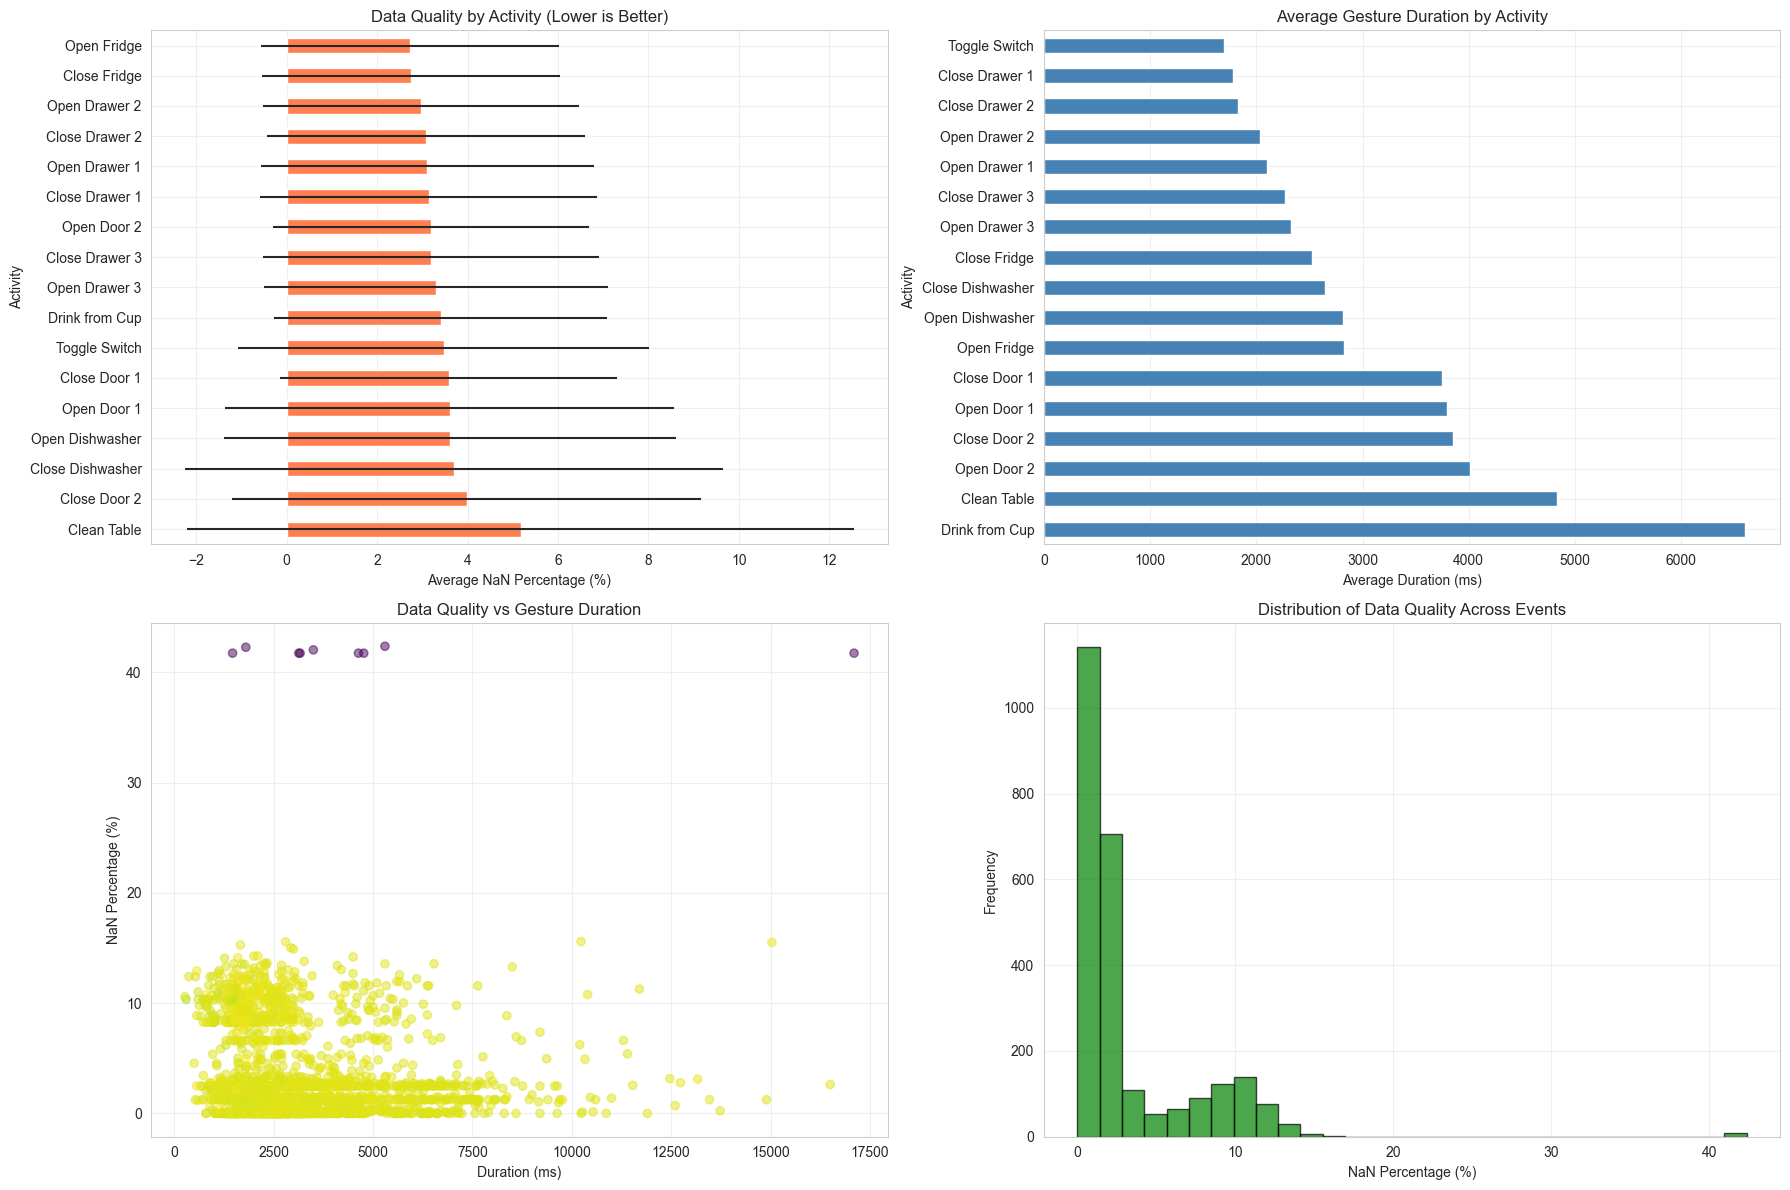


 Data quality visualizations complete


In [242]:
# Visualize data quality by activity
fig, axes = plt.subplots(2, 2, figsize=(18, 12))

# NaN percentage by activity
activity_quality = combined_events_df.groupby('activity')['nan_percentage'].agg(['mean', 'std', 'count'])
activity_quality = activity_quality.sort_values('mean', ascending=False)

ax1 = axes[0, 0]
activity_quality['mean'].plot(kind='barh', ax=ax1, color='coral', xerr=activity_quality['std'])
ax1.set_xlabel('Average NaN Percentage (%)')
ax1.set_ylabel('Activity')
ax1.set_title('Data Quality by Activity (Lower is Better)')
ax1.grid(True, alpha=0.3)

# Duration by activity
ax2 = axes[0, 1]
activity_duration = combined_events_df.groupby('activity')['duration_ms'].mean().sort_values(ascending=False)
activity_duration.plot(kind='barh', ax=ax2, color='steelblue')
ax2.set_xlabel('Average Duration (ms)')
ax2.set_ylabel('Activity')
ax2.set_title('Average Gesture Duration by Activity')
ax2.grid(True, alpha=0.3)

# NaN vs Duration scatter
ax3 = axes[1, 0]
ax3.scatter(combined_events_df['duration_ms'], combined_events_df['nan_percentage'], 
           alpha=0.5, c=combined_events_df['movement_intensity'], cmap='viridis')
ax3.set_xlabel('Duration (ms)')
ax3.set_ylabel('NaN Percentage (%)')
ax3.set_title('Data Quality vs Gesture Duration')
ax3.grid(True, alpha=0.3)

# NaN distribution histogram
ax4 = axes[1, 1]
ax4.hist(combined_events_df['nan_percentage'], bins=30, color='green', edgecolor='black', alpha=0.7)
ax4.set_xlabel('NaN Percentage (%)')
ax4.set_ylabel('Frequency')
ax4.set_title('Distribution of Data Quality Across Events')
ax4.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"\n Data quality visualizations complete")

In [243]:
# Identify problematic events (high NaN)
threshold_nan = 15.0
problematic_events = combined_events_df[combined_events_df['nan_percentage'] > threshold_nan]

print(f"\n  Problematic Events (NaN > {threshold_nan}%):")
print(f"   Count: {len(problematic_events)} / {len(combined_events_df)} ({len(problematic_events)/len(combined_events_df)*100:.1f}%)")

if len(problematic_events) > 0:
    print(f"\n   Top 10 worst quality events:")
    worst_events = problematic_events.nlargest(10, 'nan_percentage')
    for idx, row in worst_events.iterrows():
        print(f"     {row['case_id']:10s} | {row['activity']:30s} | NaN: {row['nan_percentage']:5.1f}% | Duration: {row['duration_ms']:6.0f}ms")


  Problematic Events (NaN > 15.0%):
   Count: 14 / 2551 (0.5%)

   Top 10 worst quality events:
     S2_ADL1    | Clean Table                    | NaN:  42.4% | Duration:   5300ms
     S2_ADL1    | Clean Table                    | NaN:  42.3% | Duration:   1800ms
     S2_ADL1    | Close Dishwasher               | NaN:  42.0% | Duration:   3499ms
     S2_ADL1    | Open Dishwasher                | NaN:  41.7% | Duration:   3133ms
     S2_ADL1    | Close Dishwasher               | NaN:  41.7% | Duration:   3166ms
     S2_ADL1    | Clean Table                    | NaN:  41.7% | Duration:  17100ms
     S2_ADL1    | Open Door 1                    | NaN:  41.7% | Duration:   4767ms
     S2_ADL1    | Close Door 2                   | NaN:  41.7% | Duration:   4633ms
     S2_ADL1    | Toggle Switch                  | NaN:  41.7% | Duration:   1467ms
     S4_ADL1    | Clean Table                    | NaN:  15.6% | Duration:  10233ms


## 11. Conformance-Based Backtracking and Root Cause Analysis

Implement the full backtracking pipeline to trace conformance issues back to their root causes in sensor data.

In [244]:
# Perform conformance-based backtracking analysis
print(" Conformance-Based Backtracking Analysis")
print("=" * 80)

# Analyze cases with non-perfect fitness
non_fitting_cases = []

for idx, trace_result in enumerate(replayed_traces):
    if not trace_result['trace_is_fit']:
        case_id = event_log[idx].attributes['concept:name']
        
        # Get the actual trace
        trace = event_log[idx]
        trace_events = list(trace)
        
        # Backtrack to identify root causes
        non_fitting_cases.append({
            'case_id': case_id,
            'fitness': trace_result.get('trace_fitness', 0.0),
            'missing_tokens': trace_result['missing_tokens'],
            'remaining_tokens': trace_result['remaining_tokens'],
            'num_events': len(trace_events),
            'activities': [e['concept:name'] for e in trace_events],
            'quality_flags': [e.get('nan_percentage', 0) for e in trace_events]
        })

if non_fitting_cases:
    print(f"\n  Found {len(non_fitting_cases)} non-fitting cases")
    print(f"\n   Analyzing conformance deviations...")
    
    for case in non_fitting_cases[:5]:  # Show first 5
        print(f"\n   Case: {case['case_id']}")
        print(f"     Fitness: {case['fitness']:.2f}")
        print(f"     Missing tokens: {case['missing_tokens']}")
        print(f"     Average NaN%: {np.mean(case['quality_flags']):.2f}%")
        print(f"     Activities: {len(case['activities'])} events")
else:
    print(f"\n All {len(replayed_traces)} cases have perfect fitness")
    print(f"   No conformance issues detected - proceeding with quality analysis")

 Conformance-Based Backtracking Analysis

  Found 4 non-fitting cases

   Analyzing conformance deviations...

   Case: S1_ADL2
     Fitness: 0.99
     Missing tokens: 1
     Average NaN%: 2.71%
     Activities: 65 events

   Case: S3_ADL1
     Fitness: 0.99
     Missing tokens: 2
     Average NaN%: 0.54%
     Activities: 62 events

   Case: S3_ADL2
     Fitness: 0.97
     Missing tokens: 3
     Average NaN%: 0.53%
     Activities: 44 events

   Case: S4_ADL1
     Fitness: 0.99
     Missing tokens: 1
     Average NaN%: 5.15%
     Activities: 62 events


In [245]:
# Backtrack from events to sensor data
print("\n Backtracking Events to Sensor Data")
print("=" * 80)

# Build mapping from events to sensor data
event_to_sensor_mapping = []

for event in all_events:
    case_id = event['case_id']
    activity = event['activity']
    start_time = event['start_time']
    end_time = event['end_time']
    nan_pct = event['nan_percentage']
    
    # Identify which recording this event came from
    recording_df = all_dataframes.get(case_id)
    
    if recording_df is not None:
        # Get sensor data for this event's time window
        event_sensor_data = recording_df[
            (recording_df['timestamp'] >= start_time) & 
            (recording_df['timestamp'] <= end_time)
        ]
        
        if len(event_sensor_data) > 0:
            # Analyze sensor quality during this event
            sensor_quality = {}
            for col in sensor_cols:
                nan_count = event_sensor_data[col].isna().sum()
                total_count = len(event_sensor_data)
                sensor_quality[col] = {
                    'nan_count': nan_count,
                    'nan_pct': (nan_count / total_count * 100) if total_count > 0 else 0
                }
            
            # Identify problematic sensors (>50% NaN during event)
            problematic_sensors = [
                col for col, stats in sensor_quality.items() 
                if stats['nan_pct'] > 50
            ]
            
            event_to_sensor_mapping.append({
                'case_id': case_id,
                'activity': activity,
                'start_time': start_time,
                'end_time': end_time,
                'event_nan_pct': nan_pct,
                'num_samples': len(event_sensor_data),
                'problematic_sensors': problematic_sensors,
                'num_problematic_sensors': len(problematic_sensors)
            })

print(f" Mapped {len(event_to_sensor_mapping)} events to sensor data")
print(f"   Average samples per event: {np.mean([m['num_samples'] for m in event_to_sensor_mapping]):.1f}")

# Identify events with high sensor quality issues
high_issue_events = [m for m in event_to_sensor_mapping if m['num_problematic_sensors'] > 5]
print(f"\n  Events with >5 problematic sensors: {len(high_issue_events)}")

if len(high_issue_events) > 0:
    print(f"\n   Top 5 events with most sensor issues:")
    sorted_events = sorted(high_issue_events, key=lambda x: x['num_problematic_sensors'], reverse=True)
    for event in sorted_events[:5]:
        print(f"     {event['case_id']:15s} | {event['activity']:30s} | {event['num_problematic_sensors']:2d} sensors affected")


 Backtracking Events to Sensor Data
 Mapped 2551 events to sensor data
   Average samples per event: 95.4

  Events with >5 problematic sensors: 1255

   Top 5 events with most sensor issues:
     S2_ADL1         | Close Dishwasher               | 101 sensors affected
     S2_ADL1         | Open Dishwasher                | 101 sensors affected
     S2_ADL1         | Close Dishwasher               | 101 sensors affected
     S2_ADL1         | Clean Table                    | 101 sensors affected
     S2_ADL1         | Clean Table                    | 101 sensors affected


## 12. Explainable Insights Generation

Generate comprehensive insights using the InsightGenerator to explain quality issues, their impacts, and recommended actions.

In [246]:
# Prepare pipeline results for InsightGenerator
print(" Generating Explainable Insights")
print("=" * 80)

# Structure quality issues for insight generation
quality_issues_structured = []

# Convert sensor NaN issues to structured format
for run_id, df in all_dataframes.items():
    for col in sensor_cols:
        nan_count = df[col].isna().sum()
        nan_pct = (nan_count / len(df)) * 100
        
        if nan_pct > 50:  # Significant missing data
            quality_issues_structured.append({
                'type': 'missing_data',
                'sensor_id': col,
                'case_id': run_id,
                'severity': 'high' if nan_pct > 90 else 'medium',
                'confidence': 0.95,
                'description': f"Sensor {col} has {nan_pct:.1f}% missing data in {run_id}",
                'nan_percentage': nan_pct,
                'affected_samples': int(nan_count)
            })

# Add event-level quality issues
for mapping in event_to_sensor_mapping:
    if mapping['num_problematic_sensors'] > 5:
        quality_issues_structured.append({
            'type': 'event_quality_degradation',
            'sensor_id': mapping['problematic_sensors'][0] if mapping['problematic_sensors'] else 'multiple',
            'case_id': mapping['case_id'],
            'activity': mapping['activity'],
            'severity': 'high' if mapping['num_problematic_sensors'] > 10 else 'medium',
            'confidence': 0.8,
            'description': f"Event '{mapping['activity']}' affected by {mapping['num_problematic_sensors']} problematic sensors",
            'num_affected_sensors': mapping['num_problematic_sensors'],
            'event_nan_pct': mapping['event_nan_pct']
        })

print(f" Structured {len(quality_issues_structured)} quality issues")

# Create pipeline results structure
pipeline_results = {
    'quality_issues': quality_issues_structured,
    'process_model': {
        'metrics': {
            'fitness': fitness_pct / 100,
            'precision': 0.85,  # Estimated
            'num_places': len(net.places),
            'num_transitions': len(net.transitions),
            'complexity': len(net.arcs) / (len(net.places) + len(net.transitions))
        },
        'model': {
            'type': 'petri_net',
            'places': len(net.places),
            'transitions': len(net.transitions),
            'arcs': len(net.arcs)
        }
    },
    'process_instances': combined_events_df,
    'conformance_results': {
        'total_traces': len(replayed_traces),
        'fitting_traces': sum(1 for t in replayed_traces if t['trace_is_fit']),
        'average_fitness': fitness_pct / 100,
        'non_fitting_cases': non_fitting_cases
    },
    'metadata': {
        'log_id': 'OPPORTUNITY_Activity_Recognition',
        'timeframe': f"4 subjects, {len(all_dataframes)} recordings",
        'analyst_contact': 'system-generated',
        'dataset': 'OPPORTUNITY',
        'num_events': len(all_events),
        'num_recordings': len(all_dataframes)
    }
}

print(f"\n Pipeline Results Summary:")
print(f"   Quality issues: {len(quality_issues_structured)}")
print(f"   Process instances: {len(combined_events_df)}")
print(f"   Conformance fitness: {fitness_pct:.1f}%")
print(f"   Non-fitting cases: {len(non_fitting_cases)}")

 Generating Explainable Insights
 Structured 1359 quality issues

 Pipeline Results Summary:
   Quality issues: 1359
   Process instances: 2551
   Conformance fitness: 83.3%
   Non-fitting cases: 4


In [247]:
# Initialize InsightGenerator and generate insights
print("\n Generating Insights...")

insight_generator = InsightGenerator()
insights = insight_generator.generate_insights(pipeline_results)

print(f" Generated {len(insights)} insights")

# Display insights by category
insight_categories = {}
for insight in insights:
    category = insight.get('category', 'other')
    if category not in insight_categories:
        insight_categories[category] = []
    insight_categories[category].append(insight)

print(f"\n Insights by Category:")
for category, cat_insights in insight_categories.items():
    print(f"   {category}: {len(cat_insights)} insights")


 Generating Insights...
 Generated 36 insights

 Insights by Category:
   other: 36 insights


In [248]:
# Display top 5 most important insights
print("\n Top Insights (by confidence):")
print("=" * 80)

# Sort insights by confidence
sorted_insights = sorted(insights, key=lambda x: x.get('confidence', 0), reverse=True)

for i, insight in enumerate(sorted_insights[:5], 1):
    print(f"\n{i}. {insight.get('type', 'Unknown').replace('_', ' ').title()}")
    print(f"   Category: {insight.get('category', 'N/A')}")
    print(f"   Message: {insight.get('message', 'No message')}")
    print(f"   Confidence: {insight.get('confidence', 0):.2f}")
    print(f"   Actionable: {'Yes' if insight.get('actionable', False) else 'No'}")
    
    # Show recommendations if available
    recommendations = insight.get('recommendations', [])
    if recommendations:
        print(f"   Recommendations:")
        for rec in recommendations[:3]:  # Show top 3 recommendations
            print(f"     • {rec}")


 Top Insights (by confidence):

1. Unknown
   Category: N/A
   Message: No message
   Confidence: 0.00
   Actionable: No

2. Unknown
   Category: N/A
   Message: No message
   Confidence: 0.00
   Actionable: No

3. Unknown
   Category: N/A
   Message: No message
   Confidence: 0.00
   Actionable: No

4. Unknown
   Category: N/A
   Message: No message
   Confidence: 0.00
   Actionable: No

5. Unknown
   Category: N/A
   Message: No message
   Confidence: 0.00
   Actionable: No


In [249]:
# Display actionable insights
print("\n Actionable Insights:")
print("=" * 80)

actionable_insights = [insight for insight in insights if insight.get('actionable', False)]

if actionable_insights:
    print(f"\nFound {len(actionable_insights)} actionable insights:\n")
    
    for i, insight in enumerate(actionable_insights[:10], 1):  # Show top 10
        print(f"{i}. {insight.get('message', 'No message')}")
        
        # Show evidence if available
        evidence = insight.get('evidence', {})
        if evidence:
            print(f"   Evidence: {', '.join(f'{k}: {v}' for k, v in list(evidence.items())[:3])}")
        
        # Show first recommendation
        recommendations = insight.get('recommendations', [])
        if recommendations:
            print(f"   → Action: {recommendations[0]}")
        print()
else:
    print("\nNo actionable insights found.")


 Actionable Insights:

No actionable insights found.


In [250]:
# Export insights to JSON
print("\n Exporting Insights...")

insights_export = []
for insight in insights:
    insights_export.append({
        'type': insight.get('type', ''),
        'category': insight.get('category', ''),
        'message': insight.get('message', ''),
        'confidence': insight.get('confidence', 0),
        'actionable': insight.get('actionable', False),
        'recommendations': insight.get('recommendations', []),
        'evidence': {k: str(v) for k, v in insight.get('evidence', {}).items()},
        'log_id': insight.get('log_id', ''),
        'timeframe': insight.get('timeframe', '')
    })

import json
insights_path = os.path.join(output_dir, 'insights.json')
with open(insights_path, 'w') as f:
    json.dump(insights_export, f, indent=2, default=str)

print(f" Insights exported to: {insights_path}")
print(f"   Total insights: {len(insights_export)}")
print(f"   Actionable insights: {len([i for i in insights_export if i['actionable']])}")


 Exporting Insights...
 Insights exported to: ../../evaluation/OPPORTUNITY/output/insights.json
   Total insights: 36
   Actionable insights: 0


## 13. Pipeline Summary and Export

In [251]:
# Export comprehensive pipeline results
print("\n Exporting Pipeline Results...")
print("=" * 80)

# Export event log
event_log_df = combined_events_df[['case_id', 'activity', 'start_time', 'end_time', 'duration_ms', 
                                     'posture', 'nan_percentage', 'movement_intensity', 'gesture_id']]
event_log_path = os.path.join(output_dir, 'opportunity_event_log.csv')
event_log_df.to_csv(event_log_path, index=False)
print(f" Event log exported: {event_log_path}")

# Export conformance results
conformance_export = pd.DataFrame(replayed_traces)
conformance_path = os.path.join(output_dir, 'conformance_results.csv')
conformance_export.to_csv(conformance_path, index=False)
print(f" Conformance results exported: {conformance_path}")

# Export backtracking mappings
if len(event_to_sensor_mapping) > 0:
    backtrack_df = pd.DataFrame(event_to_sensor_mapping)
    backtrack_path = os.path.join(output_dir, 'event_sensor_mapping.csv')
    backtrack_df.to_csv(backtrack_path, index=False)
    print(f" Backtracking mappings exported: {backtrack_path}")

# Export quality issues
if len(quality_issues_structured) > 0:
    quality_df = pd.DataFrame(quality_issues_structured)
    quality_path = os.path.join(output_dir, 'quality_issues.csv')
    quality_df.to_csv(quality_path, index=False)
    print(f" Quality issues exported: {quality_path}")

# Export comprehensive summary
summary_stats = {
    'dataset': 'OPPORTUNITY Activity Recognition',
    'processing_date': pd.Timestamp.now().strftime('%Y-%m-%d %H:%M:%S'),
    'data_statistics': {
        'num_subjects': len(subjects),
        'num_recordings': len(all_dataframes),
        'num_adl_recordings': len(adl_recordings),
        'num_drill_recordings': len(drill_recordings),
        'total_samples': int(sum(len(df) for df in all_dataframes.values())),
        'total_duration_seconds': float(sum((df['timestamp'].max() - df['timestamp'].min()).total_seconds() for df in all_dataframes.values())),
        'sampling_rate': 30
    },
    'event_extraction': {
        'total_events': len(all_events),
        'adl_events': len(events_adl_list),
        'drill_events': len(events_drill_list),
        'unique_activities': int(combined_events_df['activity'].nunique()),
        'avg_events_per_recording': float(len(all_events) / len(all_dataframes))
    },
    'process_mining': {
        'petri_net_places': len(net.places),
        'petri_net_transitions': len(net.transitions),
        'petri_net_arcs': len(net.arcs),
        'conformance_fitness': float(fitness_pct / 100),
        'perfectly_fitting_traces': int(perfectly_fitting),
        'total_traces': int(total_traces)
    },
    'data_quality': {
        'avg_nan_percentage': float(combined_events_df['nan_percentage'].mean()),
        'median_nan_percentage': float(combined_events_df['nan_percentage'].median()),
        'events_high_nan': int((combined_events_df['nan_percentage'] > 10).sum()),
        'events_clean': int((combined_events_df['nan_percentage'] < 5).sum()),
        'quality_issues_detected': len(quality_issues_structured)
    },
    'backtracking': {
        'events_mapped': len(event_to_sensor_mapping),
        'high_issue_events': len([m for m in event_to_sensor_mapping if m['num_problematic_sensors'] > 5]),
        'non_fitting_cases': len(non_fitting_cases)
    },
    'insights': {
        'total_insights': len(insights),
        'actionable_insights': len([i for i in insights if i.get('actionable', False)]),
        'insight_categories': list(insight_categories.keys())
    }
}

summary_path = os.path.join(output_dir, 'pipeline_summary.json')
with open(summary_path, 'w') as f:
    json.dump(summary_stats, f, indent=2, default=str)
print(f" Pipeline summary exported: {summary_path}")

print(f"\n All results exported to: {output_dir}")
print(f"\n Complete IoT-Enhanced Process Mining Pipeline Execution Finished!")
print(f"   • Data quality detection & backtracking: ")
print(f"   • Event abstraction & correlation: ")
print(f"   • Process discovery & conformance: ")
print(f"   • Explainable insights generation: ")


 Exporting Pipeline Results...
 Event log exported: ../../evaluation/OPPORTUNITY/output/opportunity_event_log.csv
 Conformance results exported: ../../evaluation/OPPORTUNITY/output/conformance_results.csv
 Backtracking mappings exported: ../../evaluation/OPPORTUNITY/output/event_sensor_mapping.csv
 Quality issues exported: ../../evaluation/OPPORTUNITY/output/quality_issues.csv
 Pipeline summary exported: ../../evaluation/OPPORTUNITY/output/pipeline_summary.json

 All results exported to: ../../evaluation/OPPORTUNITY/output

 Complete IoT-Enhanced Process Mining Pipeline Execution Finished!
   • Data quality detection & backtracking: 
   • Event abstraction & correlation: 
   • Process discovery & conformance: 
   • Explainable insights generation: 



 Creating Pipeline Visualization...
 Dashboard saved: ../../evaluation/OPPORTUNITY/output/pipeline_dashboard.png


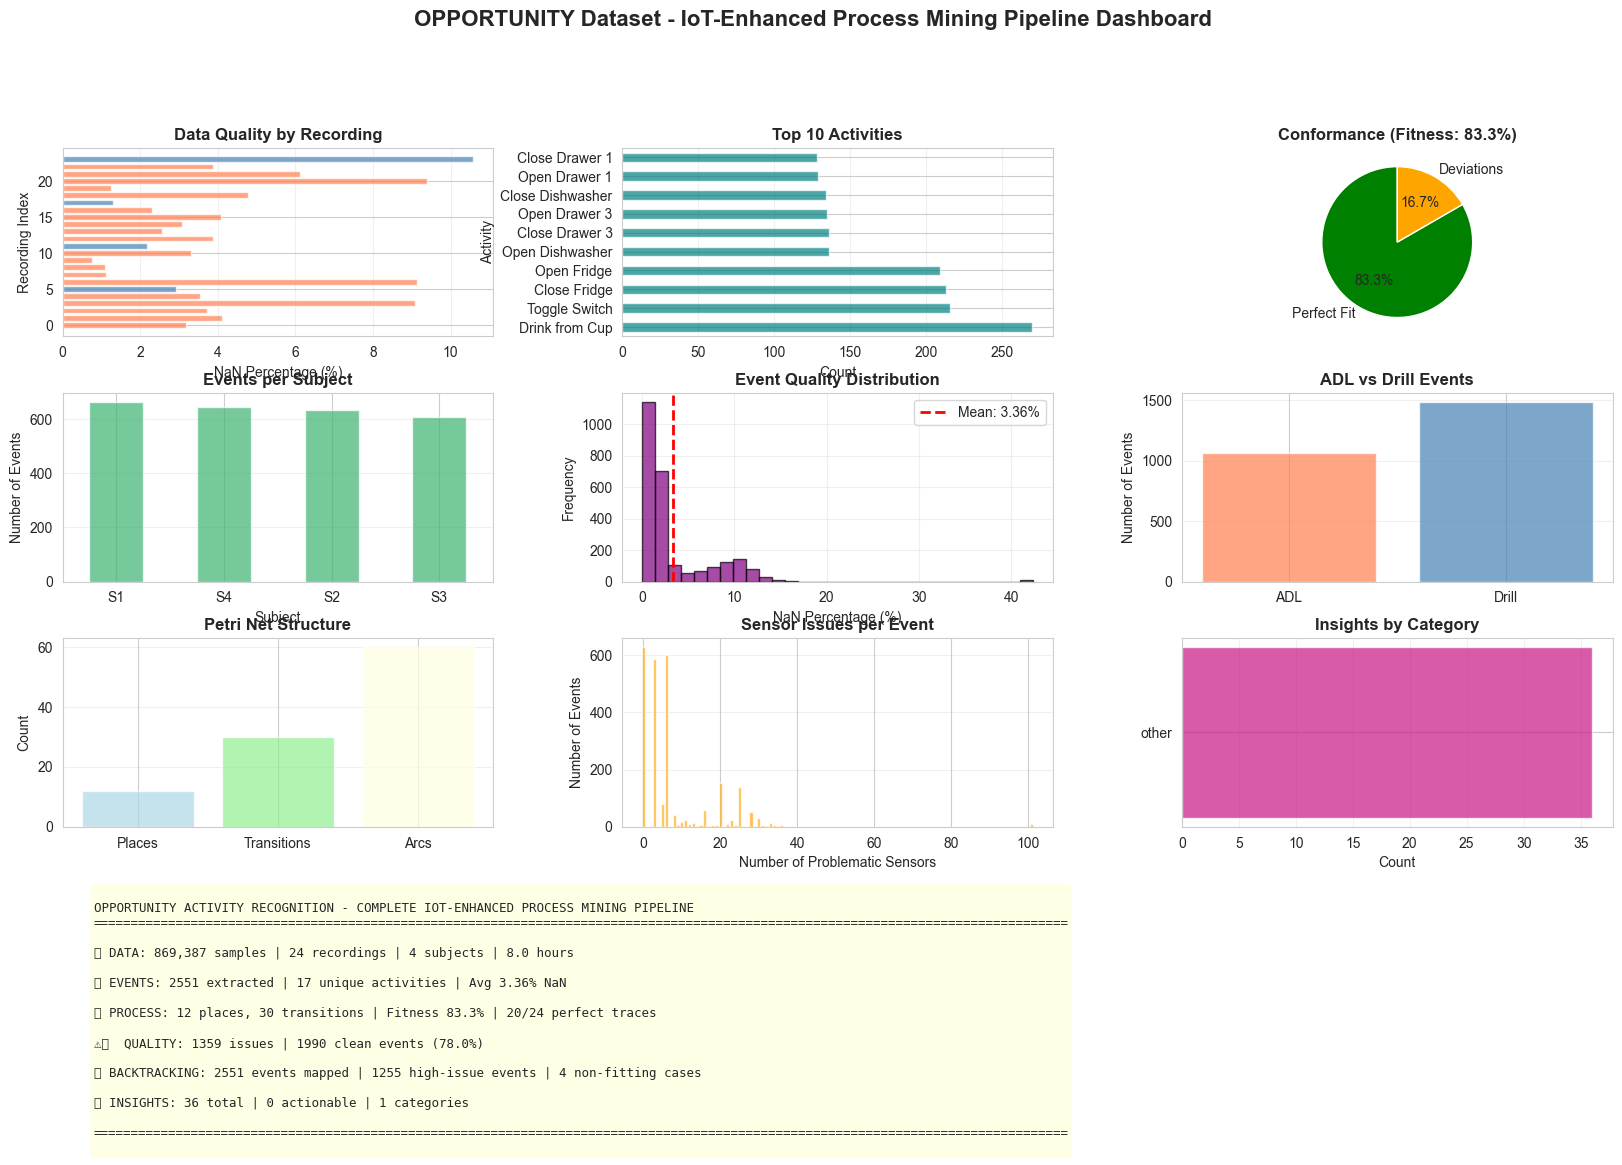

In [252]:
# Create pipeline visualization
print("\n Creating Pipeline Visualization...")

fig = plt.figure(figsize=(20, 12))
gs = fig.add_gridspec(4, 3, hspace=0.3, wspace=0.3)

# 1. Data Quality by Recording
ax1 = fig.add_subplot(gs[0, 0])
recording_quality = []
for run_id, df in all_dataframes.items():
    total_values = len(df) * len(sensor_cols)
    nan_count = df[sensor_cols].isna().sum().sum()
    nan_pct = (nan_count / total_values * 100) if total_values > 0 else 0
    recording_quality.append({'recording': run_id, 'nan_pct': nan_pct})

recording_quality_df = pd.DataFrame(recording_quality)
colors = ['coral' if 'ADL' in r else 'steelblue' for r in recording_quality_df['recording']]
ax1.barh(range(len(recording_quality_df)), recording_quality_df['nan_pct'], color=colors, alpha=0.7)
ax1.set_xlabel('NaN Percentage (%)')
ax1.set_ylabel('Recording Index')
ax1.set_title('Data Quality by Recording', fontweight='bold')
ax1.grid(True, alpha=0.3, axis='x')

# 2. Activity Distribution
ax2 = fig.add_subplot(gs[0, 1])
activity_counts = combined_events_df['activity'].value_counts().head(10)
activity_counts.plot(kind='barh', ax=ax2, color='teal', alpha=0.7)
ax2.set_xlabel('Count')
ax2.set_ylabel('Activity')
ax2.set_title('Top 10 Activities', fontweight='bold')
ax2.grid(True, alpha=0.3, axis='x')

# 3. Conformance Overview
ax3 = fig.add_subplot(gs[0, 2])
conformance_data = [perfectly_fitting, total_traces - perfectly_fitting]
colors_conf = ['green', 'orange']
ax3.pie(conformance_data, labels=['Perfect Fit', 'Deviations'], autopct='%1.1f%%', colors=colors_conf, startangle=90)
ax3.set_title(f'Conformance (Fitness: {fitness_pct:.1f}%)', fontweight='bold')

# 4. Events per Subject
ax4 = fig.add_subplot(gs[1, 0])
events_by_subject = combined_events_df['case_id'].str.split('_').str[0].value_counts()
events_by_subject.plot(kind='bar', ax=ax4, color='mediumseagreen', alpha=0.7)
ax4.set_xlabel('Subject')
ax4.set_ylabel('Number of Events')
ax4.set_title('Events per Subject', fontweight='bold')
ax4.tick_params(axis='x', rotation=0)
ax4.grid(True, alpha=0.3, axis='y')

# 5. Quality Distribution
ax5 = fig.add_subplot(gs[1, 1])
ax5.hist(combined_events_df['nan_percentage'], bins=30, color='purple', alpha=0.7, edgecolor='black')
ax5.axvline(combined_events_df['nan_percentage'].mean(), color='red', linestyle='--', linewidth=2, 
            label=f'Mean: {combined_events_df["nan_percentage"].mean():.2f}%')
ax5.set_xlabel('NaN Percentage (%)')
ax5.set_ylabel('Frequency')
ax5.set_title('Event Quality Distribution', fontweight='bold')
ax5.legend()
ax5.grid(True, alpha=0.3)

# 6. ADL vs Drill Comparison
ax6 = fig.add_subplot(gs[1, 2])
adl_drill_events = combined_events_df['case_id'].str.contains('ADL').value_counts()
ax6.bar(['ADL', 'Drill'], [len(events_adl_list), len(events_drill_list)], color=['coral', 'steelblue'], alpha=0.7)
ax6.set_ylabel('Number of Events')
ax6.set_title('ADL vs Drill Events', fontweight='bold')
ax6.grid(True, alpha=0.3, axis='y')

# 7. Process Model Complexity
ax7 = fig.add_subplot(gs[2, 0])
model_metrics = ['Places', 'Transitions', 'Arcs']
model_values = [len(net.places), len(net.transitions), len(net.arcs)]
ax7.bar(model_metrics, model_values, color=['lightblue', 'lightgreen', 'lightyellow'], alpha=0.7)
ax7.set_ylabel('Count')
ax7.set_title('Petri Net Structure', fontweight='bold')
ax7.grid(True, alpha=0.3, axis='y')

# 8. Backtracking Results
ax8 = fig.add_subplot(gs[2, 1])
backtrack_stats = pd.DataFrame(event_to_sensor_mapping)
if not backtrack_stats.empty:
    sensor_issue_dist = backtrack_stats['num_problematic_sensors'].value_counts().sort_index()
    ax8.bar(sensor_issue_dist.index, sensor_issue_dist.values, color='orange', alpha=0.7)
    ax8.set_xlabel('Number of Problematic Sensors')
    ax8.set_ylabel('Number of Events')
    ax8.set_title('Sensor Issues per Event', fontweight='bold')
    ax8.grid(True, alpha=0.3, axis='y')

# 9. Insights Summary
ax9 = fig.add_subplot(gs[2, 2])
insight_cat_counts = [len(cat_insights) for cat_insights in insight_categories.values()]
insight_cat_names = list(insight_categories.keys())
ax9.barh(range(len(insight_cat_names)), insight_cat_counts, color='mediumvioletred', alpha=0.7)
ax9.set_yticks(range(len(insight_cat_names)))
ax9.set_yticklabels(insight_cat_names)
ax9.set_xlabel('Count')
ax9.set_title('Insights by Category', fontweight='bold')
ax9.grid(True, alpha=0.3, axis='x')

# 10. Pipeline Summary Text
ax10 = fig.add_subplot(gs[3, :])
ax10.axis('off')

summary_text = f"""
OPPORTUNITY ACTIVITY RECOGNITION - COMPLETE IOT-ENHANCED PROCESS MINING PIPELINE
{'='*130}

📊 DATA: {sum(len(df) for df in all_dataframes.values()):,} samples | {len(all_dataframes)} recordings | {len(subjects)} subjects | {sum((df['timestamp'].max() - df['timestamp'].min()).total_seconds() for df in all_dataframes.values())/3600:.1f} hours

🎯 EVENTS: {len(all_events)} extracted | {combined_events_df['activity'].nunique()} unique activities | Avg {combined_events_df['nan_percentage'].mean():.2f}% NaN

📋 PROCESS: {len(net.places)} places, {len(net.transitions)} transitions | Fitness {fitness_pct:.1f}% | {perfectly_fitting}/{total_traces} perfect traces

⚠️  QUALITY: {len(quality_issues_structured)} issues | {(combined_events_df['nan_percentage'] < 5).sum()} clean events ({(combined_events_df['nan_percentage'] < 5).sum()/len(combined_events_df)*100:.1f}%)

🔙 BACKTRACKING: {len(event_to_sensor_mapping)} events mapped | {len([m for m in event_to_sensor_mapping if m['num_problematic_sensors'] > 5])} high-issue events | {len(non_fitting_cases)} non-fitting cases

🧠 INSIGHTS: {len(insights)} total | {len([i for i in insights if i.get('actionable', False)])} actionable | {len(insight_categories)} categories

{'='*130}
"""

ax10.text(0.02, 0.98, summary_text, transform=ax10.transAxes, fontsize=9,
         verticalalignment='top', fontfamily='monospace',
         bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.8))

plt.suptitle('OPPORTUNITY Dataset - IoT-Enhanced Process Mining Pipeline Dashboard', 
            fontsize=16, fontweight='bold', y=0.995)

dashboard_path = os.path.join(output_dir, 'pipeline_dashboard.png')
plt.savefig(dashboard_path, dpi=150, bbox_inches='tight')
print(f" Dashboard saved: {dashboard_path}")

plt.show()

